- Course = TU060 - MSc - Part Time - Data Science
- Module  = Machine Learning - SPEC9270
- Lecturer - Bojan Božić 
- Student name = eamonn kelly
- student numebr = D24127620

- Assignment - Apr 2026

**NOTE**: This file will take between 15 - 20 mins to run from start to finish. Also, the files 'trainingset.txt and 'query.txt' must be in the same folder as this notebook when this file is run.


## Table of Contents

This ToC is to provide an overview of the files content and ease navigation

1. Step 1 - Import the Data sets
1. Step 2 - Data Exploration
    1. 2.1 - Check Training and Query Datasets features and names are identical
    1. 2.2 - Check data types per column
    1. 2.3 - Create profiling report
    1. 2.4 - Visualise the Categorical features
    1. 2.5 - Visualise the Numerical features
    1. 2.6 - View Training data structure, statistics and cleanliness
    1. 2.7 - Additional 'age' category analysis
    1. 2.8 - Additional 'job' category value count analysis
    1. 2.9 - Additional 'campaign' feature predictor analysis
    1. 2.10 - Additional 'education' feature predictor analysis
    1. 2.11 - Additional 'balance' feature predictor analysis
    1. 2.12 - Additional 'loan' feature predictor analysis
    1. 2.13 - Additional 'contact' feature predictor analysis
    1. 2.14 - Additional 'day' feature predictor analysis
    1. 2.15 - Additional 'month' feature predictor analysis
    1. 2.16 - Additional 'poutcome' feature predictor analysis
    1. 2.17 - Feature collinearity check
    1. 2.18 - Feature Analysis Results and Next Steps Outline
1. Step 3 - Pre-processing
    1. 3.1 - Outline Summary of Feature Actions
    1. 3.2 - Remove 'duration' feature
    1. 3.3 - Remove duplicates from training data only
    1. 3.4 - Feature Engineering - Create new feature 'contacted_previously' from 'pdays' feature
    1. 3.5 - 'pdays' updated > replace '-1' values in pdays with '0' values
    1. 3.6 - Binary conversion of 'default', 'housing' and 'loan' feature yes/no values to 1/0
    1. 3.7 - Binary conversion of target variable 'y' TypeA/TypeB values to 0/1 - Training Data Only
    1. 3.8 - log transformation of 'balance', 'campaign', 'pdays', and 'previous'
    1. 3.9 - Information Gain - Filter based feature selection  - for numerical data
    1. 3.10 - CHi Squared feature selection  - for categorical data
    1. 3.11 - Train / Test split and pipeline
    1. 3.12 - Build Pipeline and train 5 models
    1. 3.13 - AUC ROC Plot and classification
    1. 3.14 - Model evaluations and assessments
1. Step 4 - Model Tuning and validation
    1. 4.1 - Threshold Tuning
    1. 4.2 - Threshold Tuning results
    1. 4.3 - Cross Validation 
    1. 4.4 - Cross Validation results
    1. 4.5 - Address Imbalance using Oversampling
    1. 4.6 - RandomOverSampler results
    1. 4.7 - Parameter tuning using GridsearchCV
    1. 4.8 - Parameter tuning using GridsearchCV Results
1. Step 5 - Predict Query data set outcomes and Generate Answer file
    1. 5.1 - Generate Prediction on Query set using threshold value of 0.2
    1. 5.2 - Query Data set prediction results
    1. 5.3 - Generate answer file 
1. Step 6 - Conclusions

In [1]:
import numpy as np
import pandas as pd
import os
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import feature_extraction, model_selection, naive_bayes, metrics
from IPython.display import Image
import warnings
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler # to handle imbalanced data > 
from sklearn.model_selection import train_test_split, cross_validate # used to split data into training and testing
from sklearn.impute import SimpleImputer # used to address missnig values
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
# MinMax , RobustScalar  also - depends on yoour data, whichever suits your data best to get best result..
# to get between zero and 1 as mean of zero and a std dev of 1
from sklearn.compose import ColumnTransformer # used to apply transformation for selected columns
from sklearn.pipeline import Pipeline # used to create structured workflow for classification model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # used in this lab
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif, chi2
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, precision_score # accuracy and classification report, f1, recall, support all included in classification report


warnings.filterwarnings("ignore")
%matplotlib inline  

## Objective

To develop a machine learning model which will predict a 'TypeB' outcome in a provided query dataset, based off patterns learned from a provided training data set.

## Step 1 - Import the Data sets

**NOTE:** The dataset provided is based of the [UCI - Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) data. We will base our details and understanding of the individual features for this assignment from this **UCI Bank Marketing** data set, from previous experience and exposure to this and related datasets.

the dataset and some details are also available here [Kaggle - UCI Bank Marketing dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset/data)


There are two txt files provided
- 'trainingset.txt'
- 'queries.txt'

We will import them and make them available in a dataframe for analysis and data exploration

In [2]:
# import training set and query set
# Putting the data set files and this notebook file in the same directory and the script should run fine.
print(os.getcwd())
path=os.getcwd()
file_path_train = os.path.join(path, 'trainingset.txt')
file_path_queries = os.path.join(path, 'queries.txt')


df_ts = pd.read_csv(file_path_train, sep = ",", encoding='latin-1')
df_qry = pd.read_csv(file_path_queries, sep = ",", encoding='latin-1')

# noticed some whitespace in one of the feature names during early data exploration, so stripping whitespace and making all lower here to standardise the feature names across both training data and query dataset
# put all columns into lower and strip any white spaces
df_ts.columns = df_ts.columns.str.strip().str.lower()
df_qry.columns = df_qry.columns.str.strip().str.lower()

print(f" training set shape = {(df_ts.shape)}")
print(f" query set shape = {(df_qry.shape)}")


e:\GG\Msc\ML_SPEC9270_bojan_thurs\github\ml_spec9270_bojan_thurs\assignments\working\final
 training set shape = (27272, 17)
 query set shape = (17939, 17)


In [3]:
# just look at first few training set rows, see what the data is like
df_ts.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,44,JobCat9,single,secondary,no,29,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
1,47,JobCat3,married,unknown,no,1506,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
2,31,unknown,single,unknown,no,1,no,no,unknown,5,may,0,1,-1,0,unknown,TypeA
3,26,JobCat6,single,tertiary,no,447,yes,yes,unknown,5,may,0,1,-1,0,unknown,TypeA
4,42,JobCat4,divorced,tertiary,yes,2,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA


In [4]:
# just look at first few queryset rows, see what the data is like
df_qry.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,JobCat6,married,tertiary,no,2143,yes,no,unknown,5,may,0,1,-1,0,unknown,?
1,31,JobCat4,married,secondary,no,2,yes,yes,unknown,5,may,0,1,-1,0,unknown,?
2,33,JobCat6,married,tertiary,no,231,yes,no,unknown,5,may,0,1,-1,0,unknown,?
3,43,JobCat9,single,secondary,no,593,yes,no,unknown,5,may,0,1,-1,0,unknown,?
4,27,JobCat11,single,secondary,no,390,yes,no,unknown,5,may,0,1,-1,0,unknown,?


## Step 2 - Data Exploration

We will perform our initial exploratory data analysis on the training set. After applying any pre-processing steps necessary to the training set will then apply same pre-processing steps to the query data set, to make sure they are aligned and in sync, before we run predictive model on the query data.

### 2.1 - Check training and query dataset features names are identical

First part is to check feature names match across training and query sets  

In [5]:
# create a list of feature names which we will compare
print(' === training data columns ===')
df_ts_col_name = (df_ts.columns.tolist())
print(df_ts_col_name)
print("\n")

# create a list of query features names
print('=== query data columns ===')
df_qry_col_name = (df_qry.columns.tolist())
print(df_qry_col_name)
print("==== \n")

# compare the lists for training and query to see if they match or not using comparison operator
if df_ts_col_name == df_qry_col_name:
    print( "training and query data set column names match \n ")
else:
    print("column name mismatch \n")
    # we'll use sets to see what the differences are across the two lists
    ts_feature_set = set(df_ts_col_name)
    qry_feature_set = set(df_qry_col_name)
    print("=== features only in Train data set === \n")
    print(ts_feature_set - qry_feature_set)
    print("\n")
    print(" ===features only in Query data set === \n")
    print(qry_feature_set - ts_feature_set)

print(df_ts.shape)

print(df_qry.shape)

 === training data columns ===
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


=== query data columns ===
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
==== 

training and query data set column names match 
 
(27272, 17)
(17939, 17)


#### 2.2 - Check data types per column

A  check to make sure the training and query sets align in terms of data types

In [6]:
# create a list of the feature object types for training set
print(' === training data columns ===')
df_ts_dtypes= (df_ts.dtypes.tolist())
print(df_ts_dtypes)
print("\n")

# create a list of the feature object types for query set
print('=== query data columns ===')
df_qry_dtypes = (df_qry.dtypes.tolist())
print(df_qry_dtypes)
print("==== \n")

# we'll align the columns first to make sure the dtypes line up to the same columns in both datasets
# using sets to get only the column names that appear in both
aligned_cols = df_ts.columns.intersection(df_qry.columns)

# create a dataframe putting those aligned column names from both training and query into a key value pair dictionary
dtypes_ts_qry = pd.DataFrame({
    'train_dtypes' : df_ts[aligned_cols].dtypes,
    'query_dtypes' : df_qry[aligned_cols].dtypes
    
})

# have a look at the dictionary content containing intersection of both i.e. columns appearing in both
print(dtypes_ts_qry)
print("==== \n ====")

# create a list object which contains any columns which are not present in both training and query
dtype_diffs = dtypes_ts_qry[dtypes_ts_qry["train_dtypes"] != dtypes_ts_qry["query_dtypes"]]


# create for loop to check if the differences list is empty or not, if its empty there ar not difference they ar both the same
# if the list contains anything there is a difference between taring and query
# and print statement to state if theres a difference or not
if dtype_diffs.empty:
    print( " === ** Training and Query data set dtypes match ** ===")
else:
    print("=== dtypes mismatch ===")
    print(dtype_diffs)

# we'll continue to print shape of both to make sure nothing has changed as we go...
print(df_ts.shape)
print(df_qry.shape)

 === training data columns ===
[dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O')]


=== query data columns ===
[dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O')]
==== 

          train_dtypes query_dtypes
age              int64        int64
job             object       object
marital         object       object
education       object       object
default         object       object
balance          int64        int64
housing         object       object
loan            object       object
contact         object       object
day              int64        int64
month           object       object
duration         int64        int64

### 2.3 Create profiling report

We will now explore the training set data, initially by generating a profiling report and reviewing the output. This just acts as a quick and easy way to get a feel for the data.

Given the training and query set are aligned in terms of features and dtypes. We will just analyse the trainingset as results from that will be applicable to the query set. Any subsequent changes we make then to the training dataset we will also apply to the query set to ensure alignment, but we will not mix the two data sets at any stage, to prevent data leakage

In [7]:
# starting off with a profile report
profile_ts = ProfileReport(df_ts)

In [8]:
# we'll now call the generated profiling report to view it
profile_ts

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### 2.4 - Visualise the Categorical Features

We'll visualise the categorical features to get a feel for them together

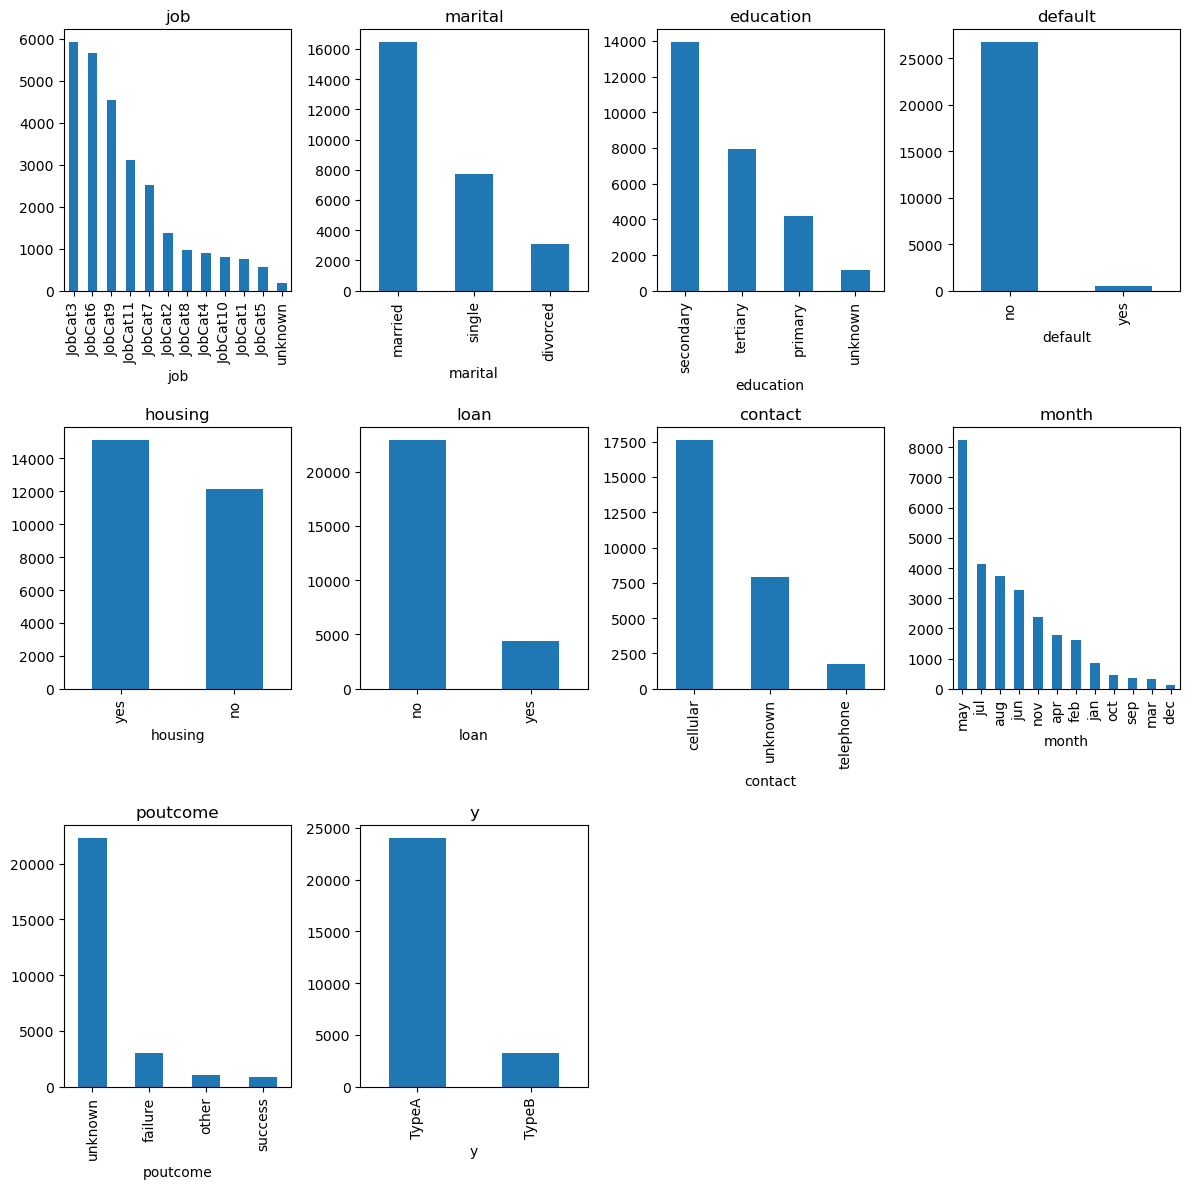

In [9]:
# Categorical Plots
# List of categorical columns
# categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
# we'll create a categorical feature list by taking features with object type = 'object'
categorical_columns = df_ts.select_dtypes(include=['object']).columns

#  the number of columns we'll display in the chart output - defined by trial and error and what looks acceptable
n_cols = 4 

# to make sure we have enough rows for all the columns, how many rows do we need to display all the categorical fatures
# a grid plot with 4 columns
# we'll check if the number of columns of that type is divisible by the number of columns we defined
if len(categorical_columns) % n_cols == 0:  
    # if it is divisible (no remainder)
    n_rows = int(len(categorical_columns) / n_cols)
else:  # if it is not divisible (remainder)
    n_rows = int(len(categorical_columns) / n_cols) + 1

# define the figure and its subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 12)) 

# Holding values for the current columns and rows of the plot we are at
cur_col = 0 
cur_row = 0  

# Iterate over the column's names
for column_name in categorical_columns:
    # Plot the value counts for each categorical column
    df_ts[column_name].value_counts().plot(kind='bar', ax=axes[cur_row, cur_col], title=column_name)
    
    # Move to the next column
    cur_col += 1
    
    # After, we must check we are still within the boundaries
    if cur_col == n_cols:  # if we are beyond the boundary:
        cur_row += 1  #  increment the row count)
        cur_col = 0  # reset the count of columns - position at the first column

# Remove unused axes if number of columns doesn't fill the grid perfectly
# check for the number of categorical axes
for ax in axes.flat[len(categorical_columns):]:
    ax.remove()

# do a  tight layout
plt.tight_layout()

# View the plots
plt.show()

### 2.5 - Visaualise the Numerical features

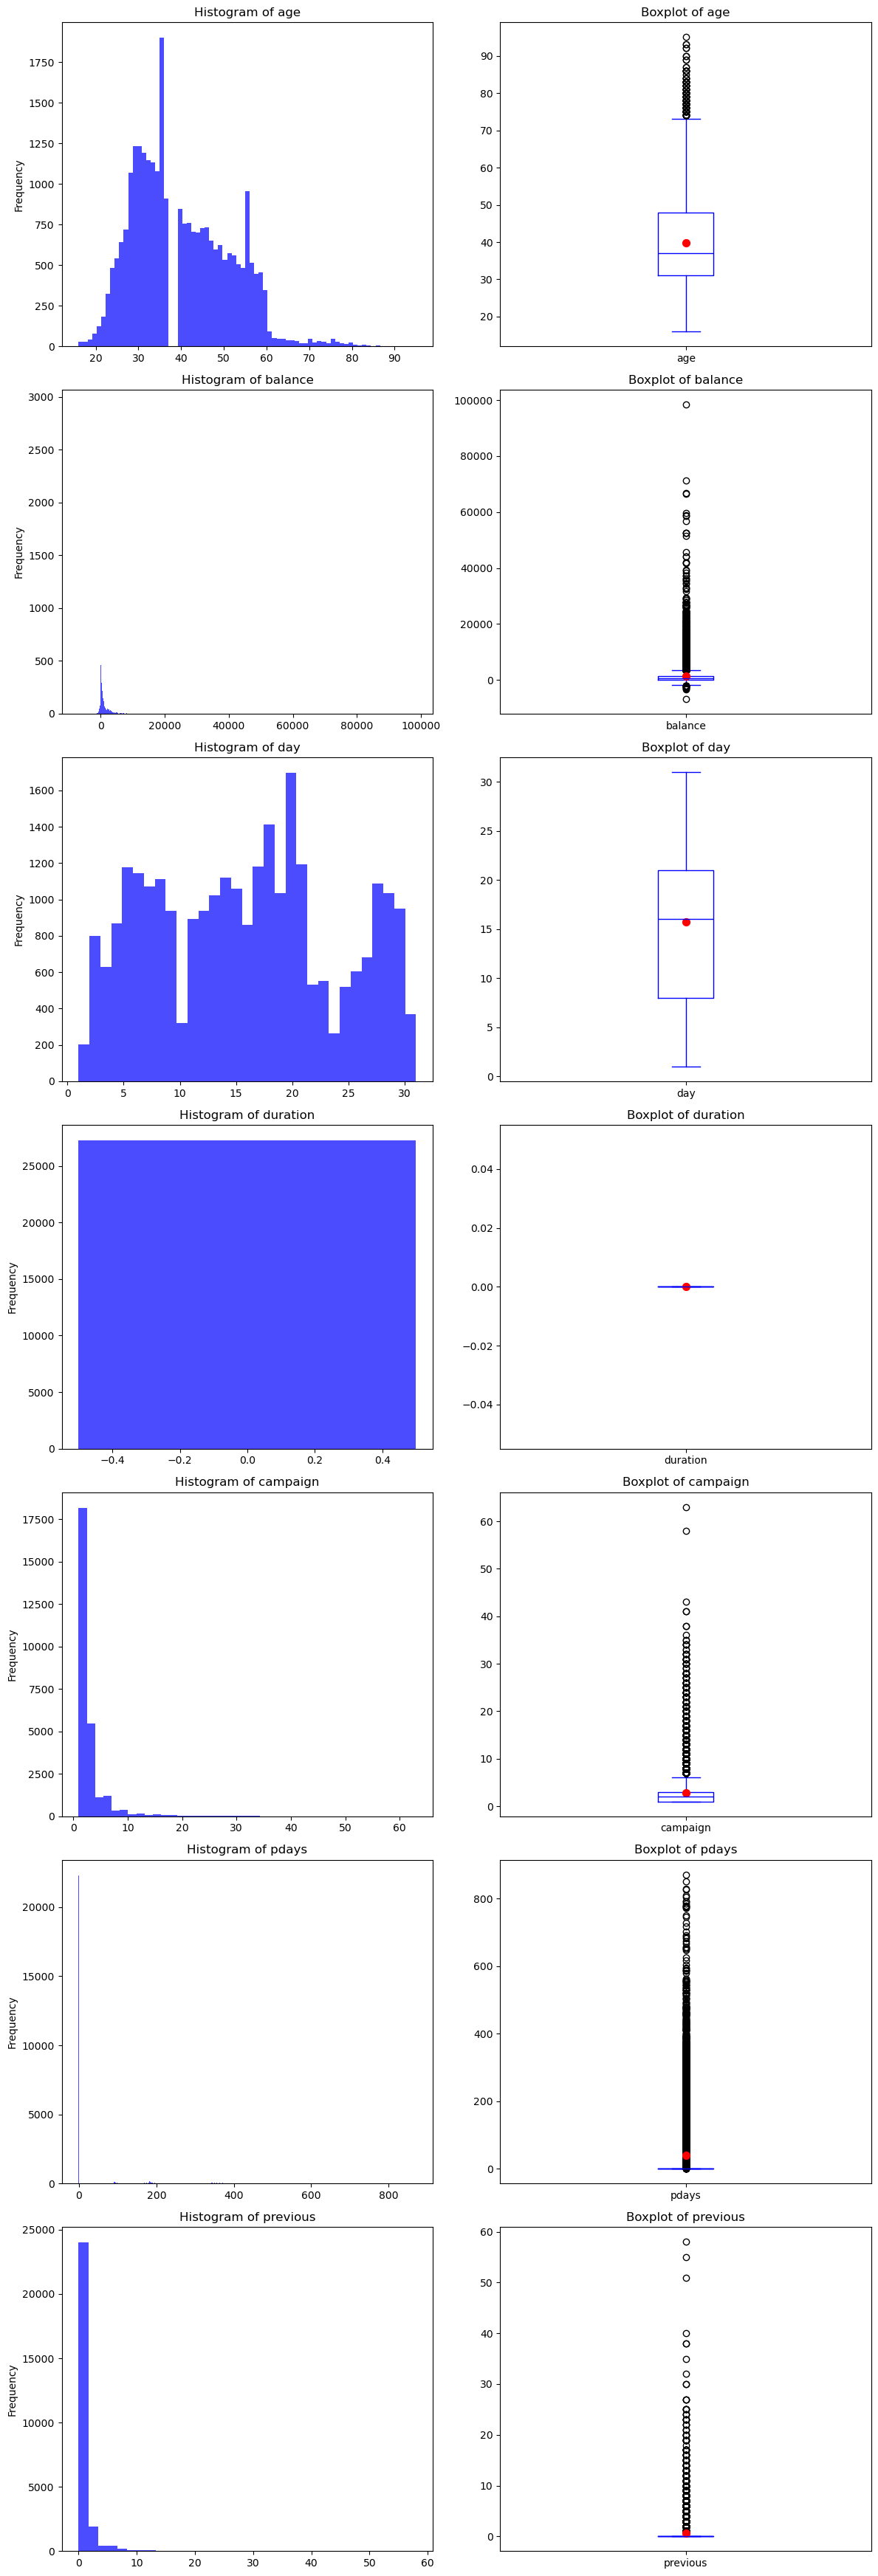

In [10]:
# Select numeric columns
## include=['number'] tells pandas to filter columns that have a numeric data type, i.e int64 or float64 as per above.
# we'll create a numerical feature list by taking features with object type = 'number' to catch both 'int' and 'float' dtypes
numeric_columns = df_ts.select_dtypes(include=['number']).columns

# create subplots: (# of rows,(number(len) of numeric columns) *2 columns one for histogram and one for boxplot. 
## Figsize here is doing 12 inches width and height is 5, but making it longer for the amount of numerical data hence len(numeric_columns)
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(12, 5 * len(numeric_columns)))



for i, col in enumerate(numeric_columns):
    # Calculate mean for each varaible for use in the scatterplot below 
    mean_value = df_ts[col].mean()

    ### Note here for the hsitograms we are using the number of bins assocaited with nunque of the varaibles. 
    num_bins = df_ts[col].nunique()
    
    # Histogram: 50 bins, 70% transparcency, blue, put it in row(i) starting from 0 and col 0 so first column.
    df_ts[col].plot(kind='hist', bins=num_bins, alpha=0.7, color='b', ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')

    # Boxplot (transposing it on its side and adding the mean per variable ina scatter plot)
    df_ts[col].plot(kind='box', color='b', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    # Trying to get the boxplot to stay within th eimage, struggling with this part. 
    #axes[i, 1].set_xlim(bankdf[col].min() - 5, bankdf[col].max() + 5)
    # Adding scatterplit just ot have mean as a dot
    # Z order is to overlay the mean on the graph kind of like ggplot2
    axes[i, 1].scatter(1,mean_value, color='red', s=50, zorder = 2) 


# do a  tight layout
plt.tight_layout()

# View the plots
plt.show()

### 2.6 - View Training data structure, statistics and cleanliness

we'll look at the structure and cleanliness of the training data set now

In [11]:
# look at the data dtypes
print(df_ts.info())
print(df_ts.shape)
print(df_qry.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27272 entries, 0 to 27271
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        27272 non-null  int64 
 1   job        27272 non-null  object
 2   marital    27272 non-null  object
 3   education  27272 non-null  object
 4   default    27272 non-null  object
 5   balance    27272 non-null  int64 
 6   housing    27272 non-null  object
 7   loan       27272 non-null  object
 8   contact    27272 non-null  object
 9   day        27272 non-null  int64 
 10  month      27272 non-null  object
 11  duration   27272 non-null  int64 
 12  campaign   27272 non-null  int64 
 13  pdays      27272 non-null  int64 
 14  previous   27272 non-null  int64 
 15  poutcome   27272 non-null  object
 16  y          27272 non-null  object
dtypes: int64(7), object(10)
memory usage: 3.5+ MB
None
(27272, 17)
(17939, 17)


In [12]:
# view statistics for numerical data
print(df_ts.describe())
print(df_ts.shape)
print(df_qry.shape)

                age       balance           day  duration      campaign  \
count  27272.000000  27272.000000  27272.000000   27272.0  27272.000000   
mean      39.880463   1361.079459     15.769287       0.0      2.739623   
std       11.426248   3015.207142      8.300983       0.0      3.011097   
min       16.000000  -6847.000000      1.000000       0.0      1.000000   
25%       31.000000     73.000000      8.000000       0.0      1.000000   
50%       37.000000    447.000000     16.000000       0.0      2.000000   
75%       48.000000   1423.000000     21.000000       0.0      3.000000   
max       95.000000  98417.000000     31.000000       0.0     63.000000   

              pdays      previous  
count  27272.000000  27272.000000  
mean      40.074105      0.578872  
std      100.200984      1.942882  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.000000  
max      871.000000     58.000000  


In [13]:
# quick look at data to see if its clean, no duplicates, corruption, unknowns,null values unusual or rogue characters etc
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , df_ts.shape[0])
print ("Columns  : " , df_ts.shape[1])
print('------')
print ("\nFeatures : \n" , df_ts.columns.tolist())
print('------')
print ("\nMissing values :  ", df_ts.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", df_ts.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(df_ts.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", df_ts.nunique())
print('------')
print('\n null values = ', df_ts.isnull().values.any())
print('------')
df_ts_missing = (df_ts=='?').sum()
print('\"  ?   \" values present =  \n',df_ts_missing)
print('------')
df_ts_unknown = (df_ts=='unknown').sum()
print('\"   unknown   \" values present =  \n',df_ts_unknown)
print('------')
df_ts_na = df_ts.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', df_ts_na)
print('------')
df_ts_none = df_ts.isin(['None', 'none']).sum()
print('    none    values present = \n', df_ts_none)
print('------')
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
rogue_ascii_df = df_ts.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", rogue_ascii_df)

Rows     :  27272
Columns  :  17
------

Features : 
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
------

Missing values :   0
------

Missing values per column:   age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
------

num of dups in df   =   7
------



Unique values :  
 age            75
job            12
marital         3
education       4
default         2
balance      5939
housing         2
loan            2
contact         3
day            31
month          12
duration        1
campaign       41
pdays         499
previous       35
poutcome        4
y               2
dtype: int64
------

 null values =  False
------
"  ?   " values present =  
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
------
"   unknown   " values present =  
 age              0
job            178
marital          0
education     1172
default          0
balance          0
housing          0
loan             0
contact       7897
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0

### 2.7 - Additional 'age' category analysis

We'll perform a deeper specific interpretative analysis of the data for this feature

In [14]:
# we will create a working dataframe for eda use here, so we keep the original clean for future use

df_ts_eda = df_ts.copy()
df_qry_eda = df_qry.copy()

# Age category exploration - print number of uses in outlier categories
print(f"Number of users who were < 18 - training data =  {len(df_ts_eda[df_ts_eda['age'] < 18])}")
print(f"Number of users who were > 75 - training data = {len(df_ts_eda[df_ts_eda['age'] > 75])}")

# we'll check just to see if there are of these at all n the query set
print(f"Number of users who were < 18 - query data = {len(df_qry_eda[df_qry_eda['age'] < 18])}")
print(f"Number of users who were > 75 - query data  = {len(df_qry_eda[df_qry_eda['age'] > 75])}")
# number who actually took out a term deposit in thse age bracket 

# only two unique values for term deposit 'yes' or 'no' - 
# we'll filter to see how many in those age groups actually signed up in the training set
print(f"Number of users who were < 18 who are typeB = {len(df_ts_eda[(df_ts_eda['age'] < 18) & (df_ts_eda['y'] == 'TypeB')])}")
print(f"Number of users who were > 75 who are typeB = {len(df_ts_eda[(df_ts_eda['age'] > 75 ) & (df_ts_eda['y'] == 'TypeB')])}")

print(df_ts.shape)
print(df_qry.shape)

Number of users who were < 18 - training data =  30
Number of users who were > 75 - training data = 156
Number of users who were < 18 - query data = 17
Number of users who were > 75 - query data  = 105
Number of users who were < 18 who are typeB = 9
Number of users who were > 75 who are typeB = 72
(27272, 17)
(17939, 17)


### 2.8 - Additional 'job' category value count analysis

We'll perform a deeper specific interpretative analysis of the data for this feature

In [15]:
# JOb category exploration - get job unique values count - we have 178 unknown - this could be unemployed or just not known... 
# we have no insight into categories within our dataset, so will leave them as is.

print(df_ts_eda['job'].value_counts())

print(df_ts.shape)
print(df_qry.shape)

job
JobCat3     5927
JobCat6     5664
JobCat9     4539
JobCat11    3102
JobCat7     2510
JobCat2     1370
JobCat8      965
JobCat4      900
JobCat10     800
JobCat1      754
JobCat5      563
unknown      178
Name: count, dtype: int64
(27272, 17)
(17939, 17)


### 2.9 - Additional 'campaign' feature predictor analysis

We'll perform a deeper specific interpretative analysis of the data for this feature

In [16]:
# number of times a user was contacted against whether or not they resulted in TypeB outcome
# ths will assist in determining the predictor relevance / importance in our dataset

# create new feature is_typeB to store if its typeB or not values. ,this is used uin subsequent eda analysis later also, as part of the eda dataframe
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)
 
# will create series of bins and associated labels to group values for easier analysis
#  single contact gets its own bin
campaign_bins   = [0, 1, 5, 10, 20, 30, 40, 50, 64]
campaign_labels = ['1', '2-5', '6-10', '11-20', '21-30', '31-40', '41-50', '51-63']

# create a new feature to store the campaign bin values
df_ts_eda['campaign_bin'] = pd.cut(df_ts_eda['campaign'], bins=campaign_bins, labels=campaign_labels, right=True)

# we'll groupby campaign bin them agregate, count of total rows, sum of typeb's and the mean valeu for converted tp tyupeB
# create summary table to display output, number of contacts, number converted to a sale, and the sale conversion rate
campaign_summary = df_ts_eda.groupby('campaign_bin', observed=True).agg(
    total           = ('is_typeB', 'count'),
    converted_to_typeB       = ('is_typeB', 'sum'),
    conversion_rate_to_typeB = ('is_typeB', 'mean')
).reset_index()

# create a feature for 'not converted'  which is total minus converted from earlier table
campaign_summary['not_converted_to_typeB']   = campaign_summary['total'] - campaign_summary['converted_to_typeB']
# create a feature for 'conversion rate'  which is convertign mean valeu to a percentage value
campaign_summary['conversion_rate_to_typeB_%'] = (campaign_summary['conversion_rate_to_typeB'] * 100).round(2)

# view the table with the listed columns
print(campaign_summary[['campaign_bin','total','converted_to_typeB', 'not_converted_to_typeB','conversion_rate_to_typeB_%']].to_string(index=False))

# will continue to just veiw the shape and make sure no mistakes and not afecting anything with original
print(f" \n training set - original - shape = {(df_ts.shape)}")
print(f" query set - original - shape = {(df_qry.shape)} \n")

# view the change in eda dataframe shape, just to keep track of it so knwo where we are and affectign the right dataframe
print(f" training set - eda dataframe - shape = {(df_ts_eda.shape)}")
print(f" query set - eda dataframe - shape = {(df_qry_eda.shape)}")



campaign_bin  total  converted_to_typeB  not_converted_to_typeB  conversion_rate_to_typeB_%
           1  10641                1569                    9072                       14.74
         2-5  14067                1526                   12541                       10.85
        6-10   1864                 117                    1747                        6.28
       11-20    565                  27                     538                        4.78
       21-30    107                   2                     105                        1.87
       31-40     23                   1                      22                        4.35
       41-50      3                   0                       3                        0.00
       51-63      2                   0                       2                        0.00
 
 training set - original - shape = (27272, 17)
 query set - original - shape = (17939, 17) 

 training set - eda dataframe - shape = (27272, 19)
 query set - eda datafram

### 2.10 - Additional 'education' feature predictor analysis


In [17]:
# this is the education level of the individual targetted
# check how many type b values there are for each education type
# this is to help us determine fi we need to include ordinal nature of education and where 'unknown' might sit

# we'll groupby education this time then agregate, count of total rows, sum of typeb's and the mean valeu for converted tp tyupeB
# create summary table to display output, number of contacts, number converted to a sale, and the sale conversion rate
edu_summary = df_ts_eda.groupby('education', observed=True).agg(
    total           = ('is_typeB', 'count'),
    typeB_count     = ('is_typeB', 'sum'),
    typeA_count     = ('is_typeB', lambda x: (x == 0).sum()),
    conversion_rate_to_typeB = ('is_typeB', 'mean')
).reset_index()


# # sort by conversion rate to typeB descending
edu_summary = edu_summary.sort_values('conversion_rate_to_typeB', ascending=False)
# convert to percentage
edu_summary['conversion_rate_to_typeB_%'] = (edu_summary['conversion_rate_to_typeB'] * 100).round(2)

# view the table with the listed columns
print(edu_summary[['education','total','typeB_count', 'typeA_count','conversion_rate_to_typeB_%']].to_string(index=False))

# will continue to just veiw the shape and make sure no mistakes and not afecting anything with original
print(f" \n training set - original - shape = {(df_ts.shape)}")
print(f" query set - original - shape = {(df_qry.shape)} \n")

# view the change in eda dataframe shape, just to keep track of it so knwo where we are and affectign the right dataframe
print(f" training set - eda dataframe - shape = {(df_ts_eda.shape)}")
print(f" query set - eda dataframe - shape = {(df_qry_eda.shape)}")



education  total  typeB_count  typeA_count  conversion_rate_to_typeB_%
 tertiary   7947         1216         6731                       15.30
  unknown   1172          169         1003                       14.42
secondary  13949         1494        12455                       10.71
  primary   4204          363         3841                        8.63
 
 training set - original - shape = (27272, 17)
 query set - original - shape = (17939, 17) 

 training set - eda dataframe - shape = (27272, 19)
 query set - eda dataframe - shape = (17939, 17)


### 2.11 - Additional 'balance' feature predictor analysis

In [18]:
# balance and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all balances

# will create series of bins and associated labels to group values for easier analysis
#  minus and zero contact gets its own bin
balance_bins   = [-7000, 0, 10000, 20000, 30000, 40000, 50000, 60000, 100000]
balance_labels = ['<0', '0-10k', '10k-20k', '20k-30k', '30k-40k', '40k-50k', '50k-60k', '60k+']

# create new feature to store the balance bin  values
df_ts_eda['balance_bin'] = pd.cut(df_ts_eda['balance'], bins=balance_bins, labels=balance_labels, right=True)

# total numebr of rows in the dataframe, used for calculation later
total_df_rows = len(df_ts_eda)

# we'll groupby balance bin this time then aggregate, 
# count of total per bucket range (so type B and TypeA), sum of typeb's and sum of typeA's per bucket
balance_summary = df_ts_eda.groupby('balance_bin', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeB_count     = ('is_typeB', 'sum'),
    typeA_count     = ('is_typeB', lambda x: (x == 0).sum()),
).reset_index()

# percentage of total in bucket that are typeB
balance_summary['typeB_%_per_bucket'] = (balance_summary['typeB_count'] / balance_summary['total'] * 100).round(2)

# percentage of whole dataset that occurs in this bucket/ balance range
balance_summary['%_of_total_in_this_bucket']   = (balance_summary['total'] / total_df_rows * 100).round(2)

# view balance bucket summary details 
print(balance_summary[['balance_bin', 'total', 'typeA_count', 'typeB_count', '%_of_total_in_this_bucket','typeB_%_per_bucket']].to_string(index=False))

# will continue to just veiw the shape and make sure no mistakes and not afecting anything with original
print(f" \n training set - original - shape = {(df_ts.shape)}")
print(f" query set - original - shape = {(df_qry.shape)} \n")

# view the change in eda dataframe shape, just to keep track of it so knwo where we are and affectign the right dataframe
print(f" training set - eda dataframe - shape = {(df_ts_eda.shape)}")
print(f" query set - eda dataframe - shape = {(df_qry_eda.shape)}")
 

balance_bin  total  typeA_count  typeB_count  %_of_total_in_this_bucket  typeB_%_per_bucket
         <0   4412         4109          303                      16.18                6.87
      0-10k  22367        19512         2855                      82.01               12.76
    10k-20k    386          320           66                       1.42               17.10
    20k-30k     74           61           13                       0.27               17.57
    30k-40k     15           12            3                       0.06               20.00
    40k-50k      6            6            0                       0.02                0.00
    50k-60k      8            6            2                       0.03               25.00
       60k+      4            4            0                       0.01                0.00
 
 training set - original - shape = (27272, 17)
 query set - original - shape = (17939, 17) 

 training set - eda dataframe - shape = (27272, 20)
 query set - eda datafram

### 2.12 - Additional 'loan' feature predictor analysis

In [19]:
# whether the individual has a loan or not
# will look to see where most of typeb's sit for who ahs a loan and who doesn't

# total number of rows in the dataframe, used for calculation later
total_df_rows = len(df_ts_eda)

# using is_typeB feature that was created earlier
# groupby loan this time then aggregate for each listed group
# count of total per category (so type B and TypeA), sum of typeb's and sum of typeA's per category
loan_summary = df_ts_eda.groupby('loan', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeB_count = ('is_typeB', 'sum'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
).reset_index()

# create new columns and the calculated values to populate them
loan_summary['%_of_total']    = (loan_summary['total'] / total_df_rows * 100).round(2)
loan_summary['%_typeB']  = (loan_summary['typeB_count'] / loan_summary['total'] * 100).round(2)
loan_summary['%_typeA']  = (loan_summary['typeA_count'] / loan_summary['total'] * 100).round(2)

# view the generated dataframe
print(loan_summary[['loan', 'total', 'typeA_count', 'typeB_count', '%_of_total', '%_typeA', '%_typeB']].to_string(index=False))

# will continue to just view the shape and make sure no mistakes and not affecting anything with original
print(f" \n training set - original - shape = {(df_ts.shape)}")
print(f" query set - original - shape = {(df_qry.shape)} \n")

# view the change in eda dataframe shape, just to keep track of it so know where we are and affecting the right dataframe
print(f" training set - eda dataframe - shape = {(df_ts_eda.shape)}")
print(f" query set - eda dataframe - shape = {(df_qry_eda.shape)}")

loan  total  typeA_count  typeB_count  %_of_total  %_typeA  %_typeB
  no  22921        19974         2947       84.05    87.14    12.86
 yes   4351         4056          295       15.95    93.22     6.78
 
 training set - original - shape = (27272, 17)
 query set - original - shape = (17939, 17) 

 training set - eda dataframe - shape = (27272, 20)
 query set - eda dataframe - shape = (17939, 17)


### 2.13 - Additional 'contact' feature predictor analysis

In [20]:
# contact is a measure of how the individual was contacted
# will look to see where most of typeB's sit for who ahs a loan and who doesn't

# total number of rows in the dataframe, used for calculation later
total_df_rows = len(df_ts_eda)

# using is_typeB feature that was created earlier
# groupby contact this time then aggregate for each listed group
# count of total per category (so type B and TypeA), sum of typeb's and sum of typeA's per category
contact_summary = df_ts_eda.groupby('contact', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeB_count = ('is_typeB', 'sum'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum())
).reset_index()

# create new columns and the calculated values to populate them
contact_summary['%_of_total']   = (contact_summary['total'] / total_df_rows * 100).round(2)
contact_summary['%_typeB'] = (contact_summary['typeB_count'] / contact_summary['total'] * 100).round(2)
contact_summary['%_typeA'] = (contact_summary['typeA_count'] / contact_summary['total'] * 100).round(2)

# view the generated dataframe
print(contact_summary[['contact', 'total', 'typeA_count', 'typeB_count', '%_of_total', '%_typeA', '%_typeB']].to_string(index=False))

# will continue to just view the shape and make sure no mistakes and not affecting anything with original
print(f" \n training set - original - shape = {(df_ts.shape)}")
print(f" query set - original - shape = {(df_qry.shape)} \n")

# view the change in eda dataframe shape, just to keep track of it so know where we are and affecting the right dataframe
print(f" training set - eda dataframe - shape = {(df_ts_eda.shape)}")
print(f" query set - eda dataframe - shape = {(df_qry_eda.shape)}")

  contact  total  typeA_count  typeB_count  %_of_total  %_typeA  %_typeB
 cellular  17633        14942         2691       64.66    84.74    15.26
telephone   1742         1515          227        6.39    86.97    13.03
  unknown   7897         7573          324       28.96    95.90     4.10
 
 training set - original - shape = (27272, 17)
 query set - original - shape = (17939, 17) 

 training set - eda dataframe - shape = (27272, 20)
 query set - eda dataframe - shape = (17939, 17)


### 2.14 - Additional 'day' feature predictor analysis

In [21]:
# day of the month when contacted
# will check if day feature has any patterns that might stand out for typeB's

# total number of rows in the dataframe, used for calculation later
total_df_rows = len(df_ts_eda)


# using 'is_typeB' feature that was created earlier
# groupby day this time then aggregate for each listed group
# count of total per category (so type B and TypeA), sum of typeA's and sum of typeA's per category
day_summary = df_ts_eda.groupby('day', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeB_count = ('is_typeB', 'sum'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum())
).reset_index()

# create new columns and the calculated values to populate them
day_summary['%_of_total']   = (day_summary['total'] / total_df_rows * 100).round(2)
day_summary['%_typeB'] = (day_summary['typeB_count'] / day_summary['total'] * 100).round(2)
day_summary['%_typeA'] = (day_summary['typeA_count'] / day_summary['total'] * 100).round(2)

# view the generated dataframe
print(day_summary[['day', 'total', 'typeA_count', 'typeB_count', '%_of_total', '%_typeA', '%_typeB']].to_string(index=False))

 day  total  typeA_count  typeB_count  %_of_total  %_typeA  %_typeB
   1    204          147           57        0.75    72.06    27.94
   2    801          688          113        2.94    85.89    14.11
   3    628          525          103        2.30    83.60    16.40
   4    869          730          139        3.19    84.00    16.00
   5   1179         1056          123        4.32    89.57    10.43
   6   1144         1032          112        4.19    90.21     9.79
   7   1072          965          107        3.93    90.02     9.98
   8   1110          991          119        4.07    89.28    10.72
   9    939          829          110        3.44    88.29    11.71
  10    321          250           71        1.18    77.88    22.12
  11    892          765          127        3.27    85.76    14.24
  12    939          800          139        3.44    85.20    14.80
  13   1022          852          170        3.75    83.37    16.63
  14   1119          996          123        4.1

### 2.15 - Additional 'month' feature predictor analysis

In [22]:
# month of the year when contacted
# will check if month feature has any patterns that might stand out for typeB's

# total number of rows in the dataframe, used for calculation later
total_df_rows = len(df_ts_eda)

# using 'is_typeB' feature that was created earlier
# groupby month this time then aggregate for each listed group
# count of total per category (so type B and TypeA), sum of typeB's and sum of typeA's per category
month_summary = df_ts_eda.groupby('month', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeB_count = ('is_typeB', 'sum'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
).reset_index()

# create new columns and the calculated values to populate them
# typeB_rate is % contacted that month who ahd typeB outcome, the rate sold that month
month_summary['%_of_total'] = (month_summary['total'] / total_df_rows * 100).round(2)
month_summary['typeB_rate']   = (month_summary['typeB_count'] / month_summary['total'] * 100).round(2)

# sort by conversion rate descending
month_summary = month_summary.sort_values('typeB_rate', ascending=False)

# view the generated dataframe
print(month_summary[['month', 'total', 'typeA_count', 'typeB_count', '%_of_total', 'typeB_rate']].to_string(index=False))

month  total  typeA_count  typeB_count  %_of_total  typeB_rate
  mar    308          143          165        1.13       53.57
  sep    371          197          174        1.36       46.90
  dec    124           68           56        0.45       45.16
  oct    451          250          201        1.65       44.57
  apr   1795         1429          366        6.58       20.39
  feb   1610         1335          275        5.90       17.08
  aug   3739         3322          417       13.71       11.15
  jan    841          756           85        3.08       10.11
  jun   3283         2951          332       12.04       10.11
  nov   2384         2149          235        8.74        9.86
  jul   4117         3754          363       15.10        8.82
  may   8249         7676          573       30.25        6.95


### 2.16 - Additional 'poutcome' feature predictor analysis

In [23]:
# poutcome is the previous campaign outcome - whether individual had a typeB outcome before or not
# will check if month feature has any patterns that might stand out for typeB's

# total number of rows in the dataframe, used for calculation later
total_df_rows = len(df_ts_eda)

# using 'is_typeB' feature that was created earlier
# groupby poutcome this time then aggregate for each listed group
# count of total per category (so type B and TypeA), sum of typeB's and sum of typeA's per category, mean is typeB per category
poutcome_summary = df_ts_eda.groupby('poutcome', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeB_count = ('is_typeB', 'sum'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum())
).reset_index()

# create new columns and the calculated values to populate them
poutcome_summary['%_of_total'] = (poutcome_summary['total'] / total_df_rows * 100).round(2)
poutcome_summary['%_typeA']    = (poutcome_summary['typeA_count'] / poutcome_summary['total'] * 100).round(2)
poutcome_summary['%_typeB']    = (poutcome_summary['typeB_count'] / poutcome_summary['total'] * 100).round(2)

# sort by conversion rate descending
poutcome_summary = poutcome_summary.sort_values('%_typeB', ascending=False)

# view the generated dataframe 
print(poutcome_summary[['poutcome', 'total', '%_of_total', 'typeA_count', '%_typeA', 'typeB_count', '%_typeB']].to_string(index=False))

poutcome  total  %_of_total  typeA_count  %_typeA  typeB_count  %_typeB
 success    906        3.32          301    33.22          605    66.78
   other   1052        3.86          871    82.79          181    17.21
 failure   2998       10.99         2621    87.42          377    12.58
 unknown  22316       81.83        20237    90.68         2079     9.32


#### 2.17 - Feature Colinearity check 

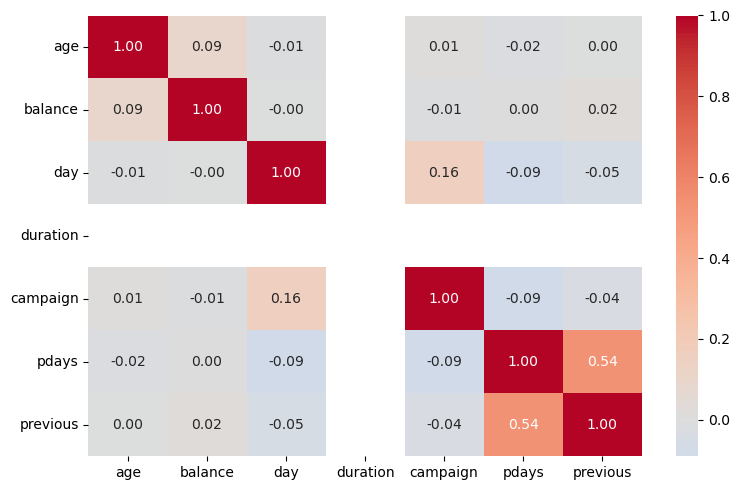

In [24]:
# Checking the correlations in numerical data - collinearity check

# will create a new eda dataframe off original, just to have a clean start again and also to leave original in clean state
df_ts_eda_2 = df_ts.copy()
df_qry_eda_2 = df_qry.copy()

# making correlation matrix

# will create a list of the numerical columns in the eda dataframe
numerical_cols = df_ts_eda_2.select_dtypes(include=['number']).columns.tolist()

# generate the correlation matrix
corr_matrix = df_ts[numerical_cols].corr()

# seaborn graph of correlation matrix
fig , ax = plt.subplots(figsize = (8,5))
sns.heatmap(corr_matrix, annot = True, fmt='.2f', cmap='coolwarm', center=0,  ax=ax)

# view matrix
plt.tight_layout()
plt.show()

### 2.18 -  Feature Analysis Results and Next Steps Outline


**NOTE:** As stated earlier, this datatset is based of the [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) data. We based our details and understanding of the individual features for this assignment as well as the details available for the **UCI Bank Marketing** data set.

we will look at them int he context of numerical and categorical features.

- **Numerical** 
    - 'age'
        - dtype = int64
        - no missing, corrupted of NaN values
        - min age = 16, max age = 95, 
        - Kurtosis ~ -0.05 / skewness ~ 0.59 / std dev ~ 11 / mean ~ 39 / median ~ 37
        - slight right skewness, with long tail to aged 95, not imbalanced and no extreme outliers.
        - Peak values land between 30 to 35 years old with IQR = 17, middle 50% of data between 31 and 48
        - There are 9 typeB outcomes for customers under 18, but there may be legal issues anyway as to whether they are valid audience, if it were real world banking data predictive modelling. 
        - There are 72 TypeB outcomes for customers who are > 75. There is predictive value in this data.
        - The query data set has 17 customers < 16 years age. Given we need to have predictions for all rows in the query data set we will keep the < 18 age group in both training and query data. 
        - Next Step >>
            - slight right skewed, not severely, 
            - Could apply Standard scalar,  z score normalization based on mean and std dev, but with slight right skew will apply RobustScalar using median + IQR making it less sensitive to the skew and outliers
            - dtype remains as is

    - 'balance'
        - dtype = int64 
        - This is the balance in peoples bank accounts
        - no missing, corrupted of NaN values
        - min = -6847, max = 98417, with 2115 '0' values  
        - Kurtosis ~ 126 / skewness ~ 8 / std dev ~ 3015 / mean ~ 1361 / median ~ 447
        - Kurtosis is leptokurtic and distribution highly right skewed... big peak near zero with long tail.. (normal distribution being = 3)
        - negative value is money owed.. big spread with extreme outliers
        - IQR = 1350, => middle 50% is tightly packed
        - Can see most sit int he 0-10K range, But the highest number of Type B outcomes are iny eh higher balance ranges i.e. 30-40K = 20% and 50-60K = 25%. While they have less customers in those brackets more of those customers have a type B outcome. 
        - From  business point of view that need to target more customers with higher bank balances to have greatest chance of getting type B outcomes.
        - log or robust scalar? - do nothing? if tre based model might be fine...
        - Next Steps
            - could benefit from being transformed 
            - Any transformation will also have to accommodate negative and zero values... as they are real data, real bank balances.
            - transform >> we could shift everything by adding 6848 to each value(addresses minus sign and zeros) + apply log1p + apply robust scalar
            - a simpler option may be to just handle outliers using Robust scalar (median and IQR)
            - Scale using Robust Scalar.. it handles negative values and also zero values...
            - It does not fix the skewness however, for RF and GB this is fine but for others i.e. LR, KNN, NB. may affect outcome. will test and try, see what works best.

    - 'day'
        - dtype = 'int64'
        - days of the month 
        - no missing, NaN, 'unknown', negative values, zeros, or corrupt data
        - min value 1 - max value  31
        - not a real numeric value, more categorical in that it represents a day of a month.
        - there are peaks and troughs which may correspond to weekends and busy days of the week, is periodic in behaviour.
        - no unusual imbalance to take account of
        - Kurtosis = ~ -1  (flat enough data no major peaks)/ skewwness = 0.096 (no skewness)
        - we could calculate the actual day of the week, as people could be more receptive on particular days of the week, however we do not have the year value to calculate it reliably, only date and month. Due to this uncertainty we will not feature engineer or add a time series component.
        - Next Steps
            - could one-hot encode but that would be adding dimensions with questionable return
            - will leave as is as int64 
            - is more categorical than numerical but will put into pipeline as numerical, low skewness means this is appropriate

    - 'duration'
        - dytype  = int64
        - how long a call lasted
        - 27272 values = '0' - no other values present, no variation or information in the data. was blank in correlation matrix as all values are zero.
        - Also, we don't know before we make a call, how long that call will last, so the usefulness of this feature is questionable.
        - Next Steps
            - we will remove the feature

    - 'campaign'
        - dtype  = 'int64'
        - number of times a user was contacted during this single campaign for which we have data.
        - no missing, NAN, zeros, negative numbers or corrupt data
        - min = 1  / max = 63 with 41 unique values. All whole numbers, no floats.
        - Kurtosis ~ 37 / skewness ~ 4 / std dev ~ 3 / mean ~ 2.7 / median ~ 2
        - 10,641 customers received only 1 call.
        - some customers were contacted up to 63 times in this campaign
        - not normally distributed - IQR - 1 to 3 but have low number outliers then out to '63'
        - sharp peak with kurtosis = 37.3 
        - long right tail with skewness of ~ 4
        - 1 contact  = ~ 14% outcome of TypeB - highest rate
        - 2 - 5 contacts = ~ 10% outcome of TypeB
        - nobody contacted > 40 times took out a term deposit and conversion rate gets less the more a user is contacted.... Ther is an inverse relationship between the number of times a customer is contacted and the number of customers taking out a term deposit. 
        - From a business perspective there is too much time in call centre ringing customers who will not buy. Worth reviewing the process based off this. If do not convert after a low, set number of contacts, do not ring them again.
        - Next Steps
            - convert to log1p to address skewness and distribution
            - followed by Scaling using RobustScalar (media / IQR) to handle the outliers
            - dtype will change to float after log tramsform

    - 'pdays'
        - dtype = 'int64' 
        - number of days since client was last contacted in an earlier campaign (previous days)
        - No missing, corrupted or NaN values
        - 499 unique values
        - (22313 ) or 81.8% are '-1', other values, 18.2%, are spread across 498 different values, no one value dominates.
        - '-1' = never contacted before, so it has no numerical relationship to the other values in the feature. rather it is a flag, which means they haven't been contacted before and as such as new customers. 
        - IQR = 0 i.e. Q1, Q2 and Q3 are all -1. i.e. the top 75% of values are all '-1' 
        - The other values being a spread of small number of occurences of a large spread of values the max of which is '871'. These are old or existing customers, some of which have not been contacted in 1, 2 or more years.
        - Kurtosis ~ 7 (a sharp peak)/ skewness ~ 2.6 (right skewed)/ std dev ~ 100 / mean ~ 40 / median = -1
        - heavily right skewed, with a long tail, large spread of data
        - Not really a continuous set of numerical variables, its more of a categorical features, mixture of two sets of information. it is a flag as to whether or not previously contacted and then some variables representig duration since last contacted.  There are two different data dtypes in the feature.
        - Next Steps
            - Will split into new columns, 
                - column 1 (new) - 'contacted_previously' binary cetegorical  > 
                    - '1' = was contacted_previously 
                    - '0' = not contacted_previously
                    - dtype = int64 > will be binary numeric , but is categorical.
                - column 2 (existing column - Retain this column)
                    - Retain numbers of days since last contacted in this column as they are
                    - change the '-1' value to '0' to indicate customer has not been contacted before.
                    - Followed by applying 'log1p' natural log transformation to reduce the skewness and reshape the distribution, this will help logistical regression and naive bayes models with data shape and scaling
                    - followed by scaling using RobustScalar as we will have 22,313 '0' values 
                    - dtype will change to float after log tramsform

    - 'previous'
        - dtype  = 'int64'
        - how many times a customer ws previously contacted.
        - no missing, negative, NaN or corrupt values
        - 35 distinct/unique values with, with a min = '0' and max = '58'
        - 81.8% (22313) are '0' which means never contacted before. This ties in with previous feature pdays which had 81.8% as '-1', meaning never contacted before, again as previously indicating new customers.
        - Kurtosis ~ 124 (a sharp peak)/ skewness ~ 8 (heavily right skewed)/ std dev ~ 1.9 / mean ~ 0.57 / median = 0
        - IQR = 0 => Q1, Q2 and Q3 are the same i.e. they are all '0'. i.e. at least 75% of values are all '0' and as can be designated as new customers.
        - Next Steps
            - Scale by applying 'log1p' natural log transformation to reduce the skewness and reshape the distribution
            - dtype will change to float after log tramsform
            - followed by scaling using RobustScalar to address skewness


    




- **Categorical**
    - 'job'
        - dtype = 'object' 
        - customer job type
        - 12 unique job types and 178 'unknown' values = 12 categories in total
        - Jobs 3, 16 and 9 dominate - JobCat3=5927(21.7%) / JobCat6=5664(20.8%) / JobCat9=4539(16.6%)
        - no missing, NAN values or corrupted data
        - we have no insight into categories within our dataset, the dataset has been annonymised, if unemployed or not, or special category high paying jobs not available, as such will leave as is, including 'unknown' job category
        - Next Steps
            - covert to binary categorical for each of the 12 categories - use one-hot encoding
            - Will increase dimensionality but no other option to convert to numerical without adding dimensions and there is predictive value in the feature
            - dtype changes to 'int'

    - 'marital'
        - dtype = 'object' 
        - marital status of customer
        - no missing, NaN, 'unknown' or corrupt data
        - 3 unique values, - 'married'=16462(~60%) / 'single'=7728(~28%) / 'divorced'= 3082(~11%) = total 27272.
        - Is imbalanced but may reflect sample population from banking perspective i.e. middle aged married have most dealign with banks, mortgages etc
        - Next Steps
            - covert to binary categorical for each category - use one-hot encoding
            - dtype will be converted to binary numeric (but is effectively still a categorical and not numeric continuous)


    - 'education'
        - dtype = 'object'
        - education level for customer
        - no missing, NaN, 'unknown' or corrupt data
        - 4 unique values  - secondary=13,949(~51%) / tertiary=7,947 (~29%) / primary=4204 (~15%) / unknown=1172 (~ 4%)
        - no insight into "unknown" value - will keep this data as is, could be useful predictor
        - There is an ordinal element to the data with secondary being higher than primary and tertiary being higher than secondary, however where does unknown fit into hierarchy.
        - 'unknown' has the second highest typeb values, at ~ 11%, after tertiary, hence is important predictor.
        - Next Steps
            - will use one-hot encoding for all 4 categories
            - increases dimensions, however need to retain 'unknown' and doesn't quite fit into ordinal data structure easily.
            - dtype convert to = 'int' (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous)

    - 'default'
        - dtype = 'object'
        - whether or not someone has previously defaulted on a loan.
        - no missing, NaN, 'unknown' or corrupt data
        - two categories - no=26788(98.2%) / yes=484(1.8%)
        - very imbalanced -
        - Real data so will keep even though heavily imbalanced
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = 'int' (although numeric is effectively binary categorical)
    
    - 'housing'
        - dtype = 'object'
        - Whether or not they own their own home
        - no missing, NaN, 'unknown' or corrupt data
        - reasonably balanced
        - 'yes' = 15131  / 'no'	= 12141 
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = 'int' (although numeric is effectively binary categorical)
    
    - 'loan'
        - dtype = 'object'
        - Whether or not they have an existing loan.
        - no missing, NaN, 'unknown' or corrupt data
        - is imbalanced
        - 'no'= 22921(84.0%) / 'yes'= 4351(16.0%)
        - 12% who have no loan are type B, whereas 6% who have loans are type B. Customers who do not have a loan are two times more ilkely to take out a term deposit and become type B customers. This makes sense as they have more disposable income.
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = 'int' (although numeric is effectively binary categorical)    

    - 'contact'
        - dtype = 'object'
        - How customers were contacted during the bank marketing campaign
        - no missing, NaN, 'unknown' or corrupt data
        - 3 values - cellular=17633 (64.7%)  /  unknown=7897(29.0%) /  telephone=1742(6.4%)
        - Imbalanced but are real values as most people do not have a land line, rather a mobile phone, the 'unknown' could be missing values, not recorded, possibly email or cold calling.
        - ~ 15% of cellular are type B, followed by ~11% for telephone and ~4% for unknown. With Cellular having the strongest performance.
        - could be related to age or a demographic younger people having mobile phones, and older people not adopting new technologies, as well as people being more open to engaging in different means of communication
        - Next Steps
            - will use one-hot encoding for all 3 categories
            - increases dimensions, however need to retain 'unknown' and doesn't quite fit into ordinal data structure easily.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous))
    
    - 'month'
        - dtype = 'object'
        - month of when contact was .
        - no missing, NaN, 'unknown' or corrupt data
        - big peak in May=8249(~30%), and then also in June, July=(4117(~ 15%)) / Aug=3729(~ 13%) and June=3283(12%)
        - big drop off in Sept=371(1.4%), Oct=451(1.7%) , Mar=308() and Dec 124()
        - Somewhat counter intuitive outcome from number of calls made
            - May = 8249 call made  > 573 (6.9%) resulted in TypeB outcome
            - Mar = 308 calls made > 165 (53.6%) resulted in TypeB outcome
            - explanations could be from a variety of factors, perhaps the customer type that ws rung, seasonal change of focus in customer, we do not have sufficient information to determine why this outcome is present. Regardless of cause month in this dataset adds a predictive value outside of the number of calls made.
        - There is some seasonality which may be a result of campaign duration
        - Next Steps
            - one-hot encoding for the months
            - will increase dimensionality but is a relevant feature with predictive value, as such the trade off should be worth this increase in dimensionality.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous))

    - 'poutcome'
        - dtype = 'object'
        - previous outcome of whether a customer took out a term deposit or not, so provides past customer outcome.
        - no missing, null or corrupt values etc
        - Imbalanced data - unknown=22316(81.8%)/ failure=2998(11.0%)/other=1052(3.9%)/success=906(3.3%)
        - 'unknown' is aligned with pdays value '-1' and previous value '0' i.e. in that it is not known previous outcome, there was no contact previously.
        - TYpeB outcome for customers who had success in previous campaign = 66% / other = 17.21% / failure = 12.58% / unknown  = 9.32%. 
        - 'success' is a very strong predictor in the dataset
        - 'Unknown' contains > 81% of the data, but has the lowest typeB outcome rate.
        - Next Step
            - one-hot encoding, binary columns.
            - drop_first=true for linear models to avoid multi colinearity - i.e. this will drop the first category to act as a reference grou, which is 'poutcome_unknown', no negative impact on RF, GB, KNN and NB
            - dtype = 'int' - change dytpe after one-hot encoding
    
    - 'y'
        - dtype = 'object'
        - Our target variable  
        - TypeA = no sale / TypeB  = sale
        - 2 unique values -  TypeA=24030(88.1%) /  TypeB=3242(11.9%)
        - Most customers did not take out a term deposit, 
        - Is imbalanced
        - We need binary predictor for who will take out a term deposit i.e. want to predict TypeB customers, who will take out a term deposit. Will need to predict a minority class
        - if just predicted typeA for every customer we would get 88% accuracy, but that would not be useful to us, we need to predict the minority class of 11% type Bs.
        - Next Steps
            - will encode - map existing values as below, as models will work in numerical values, distances and probabilities and threshold values.
                - TypeA = 0
                - TypeB = 1
            - will use stratified split in train test split
            - will not encode query dataset target column
            - will using evaluation metrics such as F1 score, recall, precision, roc-auc 
            - wil consider using class_weight= 'balanced' / RandomOverSampler / SMOTE to improve minority class prediction
            - will change to 'int64' but remain a binary categorical feature 

NOTE: all feature scaling and transformations will be applied to both training (*df_ts*), and query (*df_qry*) datasets, **except** for target variable 'y'. We will not touch target variable 'y' on the query set.

Also, we note that the correlation matrix shows some level of collinearity between 'pdays' and 'previous', with a value of 0.54. While this is real it is not at a level as to warrant deletion of one of the elements at this stage, and as such we will leave both for now. We will revisit if we have to, depending on results.

## Step 3 - Pre-processing

### 3.1 - Outline Summary of Feature Actions

We will group the features by action to make it easier to see the groupings

- Removal
    - 'duration': delete feature

- 'pdays': 
    - create new feature 'contacted_previously' 
        - dtype = 'int'
        - 1 = contacted previously 
        - 0 = not contacted previously
    - existing column
        - change '-1' value to zero + log transform using 'log1p'  + apply RobustScalar
        - name is same + dtype remains 'int'

- Scale
    - 'age': apply RobustScalar + dtype remains as 'int'
    - 'balance': apply RobustScalar + dtype remains as 'int'
    - 'day': apply RobustScalar + dtype remains as 'int'

- Log Transform then scale
    - 'campaign': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int'
    - 'previous': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int'
    - 'pdays': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int' (this is a separate step and actin performed on this feature, mentioned earlier already for feature engineering)

- One-Hot encoding
    - 'job': one-hot encoding for all 12 categories + dtype changes to 'int'     
    - 'marital': one-hot encoding for 3 values 'married', 'single' and 'divorced' + dtype changes to 'int'        
    - 'education': one-hot encoding for 4 values 'unknown', 'primary', 'secondary' and 'tertiary' + dtype changes to 'int' 
    - 'contact': one-hot encoding for 3 values 'cellular', 'unknown' and 'telephone' + dtype changes to 'int'  
    - 'month':  one-hot encoding for all 12 months + dtype changes to 'int'                    
    - 'poutcome': one-hot encoding for 4 values 'unknown', 'failure', 'other' and 'success' + dtype changes to 'int'    

- Convert text to Binary Numeric categorical
    - 'default': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int'         
    - 'housing': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int'       
    - 'loan': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int'  

- Training data only change
    - 'y': change 'TypeB' to 1 and 'TypeA' to 0 + dtype changes to 'int'           

### 3.2 - Remove 'duration' feature



In [25]:
# we will remove duration feature
# we will apply transforms to both training and query datasets as we go, to keep them aligned. Except the target variable changes.

# firstly we will crate a new working dataframe that we will use, we can then return easily to a point in tme version of it if we need.
# will base working df off original 

df_ts_1 = df_ts.copy()
df_qry_1 = df_qry.copy()

# delete then verify change in dataframe is as we expect
print(f' shape of training df = {df_ts_1.shape}')
df_ts_1 = df_ts_1.drop(['duration'], axis=1)
print(f' shape of training df after removal of duration feature  = {df_ts_1.shape}')

# delete then verify change in dataframe is as we expect
print("=============")
print(f' shape of query df = {df_qry_1.shape}')
df_qry_1 = df_qry_1.drop(['duration'], axis=1)
print(f' shape of query df after removal of duration featur = {df_qry_1.shape}')

 shape of training df = (27272, 17)
 shape of training df after removal of duration feature  = (27272, 16)
 shape of query df = (17939, 17)
 shape of query df after removal of duration featur = (17939, 16)


### 3.3 - Remove duplicates from training data only

In [26]:
# Seven duplicates were identified in earlier analysis we will remove these now. 
# A quick check here we see there are 3 duplicates. 
# These might increase compute demand or processing times, these are not significant here really and will have no affect on model performance. 
# Also, the answer file expects a certain number of rows to be returned and we would be out of sync with any answer file if we did so, resulting in potentially lower marks.

# create new working dataframe, not removing duplicates from query data
df_ts_2 = df_ts_1.copy()
df_qry_2 = df_qry_1.copy()

print(f' number of duplicates in training data = {df_ts_2.duplicated().sum()}')


print(f' shape of training df before dups remvevd= {df_ts_2.shape}')
df_ts_2 = df_ts_2.drop_duplicates()
print(f' shape of training df after dups removed = {df_ts_2.shape}')

print("=============")
print(f' number of duplicates in query data = {df_qry_2.duplicated().sum()}')
# print(f' shape of query df before dups remvevd = {df_qry_2.shape}')
# df_qry_2 = df_qry_2.drop_duplicates()
print(f' shape of query df the same as earlier not removing any duplicates = {df_qry_2.shape}')



 number of duplicates in training data = 7
 shape of training df before dups remvevd= (27272, 16)
 shape of training df after dups removed = (27265, 16)
 number of duplicates in query data = 3
 shape of query df the same as earlier not removing any duplicates = (17939, 16)


### 3.4 - Feature Engineering - Create new feature 'contacted_previously' from 'pdays' feature

In [27]:
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_3 = df_ts_2.copy()
df_qry_3 = df_qry_2.copy()

# create new binary categorical feature named 'contacted_previously' which flags whether contacted previously or not from 'pdays' feature
# value equal to -1 is the flag that means not contacted before... so in new feature not contacted before will be = 0, contacted before = 1
# using a comparison operator to compare each value in pdays to '-1', returns true/false and we convert t/f to 1 and 0 using integers using int
df_ts_3['contacted_previously'] = (df_ts_3['pdays']!=-1).astype(int)
df_qry_3['contacted_previously'] = (df_qry_3['pdays']!=-1).astype(int)

# verify changes

contacted_previously_1_ts = (df_ts_3['contacted_previously'] == 1).sum()
contacted_previously_0_ts = (df_ts_3['contacted_previously'] == 0).sum()
contacted_previously_total_ts = len(df_ts_3['contacted_previously'])
contacted_previously_1_ts_pct = (contacted_previously_1_ts / contacted_previously_total_ts * 100).round(1)
contacted_previously_0_ts_pct = (contacted_previously_0_ts / contacted_previously_total_ts * 100).round(1)

contacted_previously_1_qry = (df_qry_3['contacted_previously'] == 1).sum()
contacted_previously_0_qry = (df_qry_3['contacted_previously'] == 0).sum()
contacted_previously_total_qry = len(df_qry_3['contacted_previously'])
contacted_previously_1_qry_pct = (contacted_previously_1_qry / contacted_previously_total_qry * 100).round(1)
contacted_previously_0_qry_pct = (contacted_previously_0_qry / contacted_previously_total_qry * 100).round(1)


print("==== verify changes - training data set =====")
print(f" \n the unique values in new df feature 'contacted previously' = {df_ts_3['contacted_previously'].unique()}")
print(f' shape of training df before new feature added = {df_ts_2.shape}')
print(f' shape of training df after new feature added = {df_ts_3.shape}')
print(f" 'contacted_previously' values = '1'   (old non '-1' values ) = {contacted_previously_1_ts} /  {contacted_previously_1_ts_pct}%")
print(f" 'contacted_previously' values = '0'  (old '-1' values) = {contacted_previously_0_ts} / {contacted_previously_0_ts_pct}%")
print(f" total number of rows = {contacted_previously_total_ts}")
if contacted_previously_total_ts == contacted_previously_1_ts +contacted_previously_0_ts:
    print(" totals match = TRUE")
else:
    print("totals do not match = FALSE")
print(f" dtype = {df_ts_3['contacted_previously'].dtype}")

# verify changes Queryh dataset
print(" \n ==== verify changes - query data set =====")
print(f" \n the unique values in new df feature 'contacted previosul' = {df_qry_3['contacted_previously'].unique()}")
print(f' shape of training df before new feature added = {df_qry_2.shape}') # checkign previous df version
print(f' shape of training df after new feature added = {df_qry_3.shape}')
print(f" 'contacted_previously values' = '1'  (old non '-1' values ) = {contacted_previously_1_qry} /  {contacted_previously_1_qry_pct}%")
print(f" 'contacted_previously values' = '0' (old '-1' values) = {contacted_previously_0_qry} / {contacted_previously_0_qry_pct}%")
print(f" total rows = {contacted_previously_total_qry}")
if contacted_previously_total_qry == contacted_previously_1_qry + contacted_previously_0_qry:
    print(" totals match = TRUE")
else:
    print("totals do not match = FALSE")
print(f" dtype = {df_qry_3['contacted_previously'].dtype}")


==== verify changes - training data set =====
 
 the unique values in new df feature 'contacted previously' = [0 1]
 shape of training df before new feature added = (27265, 16)
 shape of training df after new feature added = (27265, 17)
 'contacted_previously' values = '1'   (old non '-1' values ) = 4959 /  18.2%
 'contacted_previously' values = '0'  (old '-1' values) = 22306 / 81.8%
 total number of rows = 27265
 totals match = TRUE
 dtype = int32
 
 ==== verify changes - query data set =====
 
 the unique values in new df feature 'contacted previosul' = [0 1]
 shape of training df before new feature added = (17939, 16)
 shape of training df after new feature added = (17939, 17)
 'contacted_previously values' = '1'  (old non '-1' values ) = 3298 /  18.4%
 'contacted_previously values' = '0' (old '-1' values) = 14641 / 81.6%
 total rows = 17939
 totals match = TRUE
 dtype = int32


### 3.5 - 'pdays' updated > replace '-1' values in pdays with '0' values

In [28]:
# crate working df to use, we'll use the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_4 = df_ts_3.copy()
df_qry_4 = df_qry_3.copy()

# replace all the '-1' values in 'pdays' feature with 0, indicating not previously contacted before.
df_ts_4['pdays'] = df_ts_4['pdays'].replace(-1, 0)
df_qry_4['pdays'] = df_qry_4['pdays'].replace(-1, 0)


# verify before and after values
pdays_minus_1_before_ts = (df_ts_3['pdays']==-1).sum()
pdays_minus_1_after_ts = (df_ts_4['pdays']==-1).sum()
pdays_zero_before_ts = (df_ts_3['pdays']==0).sum()
pdays_zero_after_ts = (df_ts_4['pdays']==0).sum()
pdays_not_zero_after_ts = (df_ts_4['pdays']!=0).sum()
pdays_total_num_rows_before_ts = (len(df_ts_3['pdays']))
pdays_total_num_rows_after_ts = (len(df_ts_4['pdays']))
pdays_zero_pct_ts = ((pdays_zero_after_ts /pdays_total_num_rows_after_ts) * 100).round(1)
pdays_not_zero_pct_ts = ((pdays_not_zero_after_ts /pdays_total_num_rows_after_ts) * 100).round(1)


# Verify changes in output

print("==== verify changes - training data set =====")

print(f" pdays minus 1 before {pdays_minus_1_before_ts}")
print(f" pdays minus 1 after {pdays_minus_1_after_ts}")
print(f" pdays zero before {pdays_zero_before_ts}")
print(f" pdays zero after {pdays_zero_after_ts}")
print(f" pdays total number of rows before {pdays_total_num_rows_before_ts}")
print(f" pdays total number of rows after {pdays_total_num_rows_after_ts}")
print(f" pdays zero percentage {pdays_zero_pct_ts}")
print(f" pdays not zero percentage {pdays_not_zero_pct_ts}")
print(f" pdays dtype after replace {df_ts_4['pdays'].dtype}")

# verify changes Query dataset

pdays_minus_1_before_qry = (df_qry_3['pdays']==-1).sum()
pdays_minus_1_after_qry = (df_qry_4['pdays']==-1).sum()
pdays_zero_before_qry = (df_qry_3['pdays']==0).sum()
pdays_zero_after_qry = (df_qry_4['pdays']==0).sum()
pdays_not_zero_after_qry = (df_qry_4['pdays']!=0).sum()
pdays_total_num_rows_before_qry = (len(df_qry_3['pdays']))
pdays_total_num_rows_after_qry = (len(df_qry_4['pdays']))
pdays_zero_pct_qry = ((pdays_zero_after_qry /pdays_total_num_rows_after_qry) * 100).round(1)
pdays_not_zero_pct_qry = ((pdays_not_zero_after_qry /pdays_total_num_rows_after_qry) * 100).round(1)
print(" \n ==== verify changes - query data set =====")

print(f" pdays minus 1 before {pdays_minus_1_before_qry}")
print(f" pdays minus 1 after {pdays_minus_1_after_qry}")
print(f" pdays zero before {pdays_zero_before_qry}")
print(f" pdays zero after {pdays_zero_after_qry}")
print(f" pdays total number of rows before {pdays_total_num_rows_before_qry}")
print(f" pdays total number of rows after {pdays_total_num_rows_after_qry}")
print(f" pdays zero percentage {pdays_zero_pct_qry}")
print(f" pdays not zero percentage {pdays_not_zero_pct_qry}")
print(f" pdays dtype after replace {df_qry_4['pdays'].dtype}")

==== verify changes - training data set =====
 pdays minus 1 before 22306
 pdays minus 1 after 0
 pdays zero before 0
 pdays zero after 22306
 pdays total number of rows before 27265
 pdays total number of rows after 27265
 pdays zero percentage 81.8
 pdays not zero percentage 18.2
 pdays dtype after replace int64
 
 ==== verify changes - query data set =====
 pdays minus 1 before 14641
 pdays minus 1 after 0
 pdays zero before 0
 pdays zero after 14641
 pdays total number of rows before 17939
 pdays total number of rows after 17939
 pdays zero percentage 81.6
 pdays not zero percentage 18.4
 pdays dtype after replace int64


### 3.6 - Binary conversion of 'default', 'housing' and 'loan' feature yes/no values to 1/0

In [29]:
# create working df to use, we'll use the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_5 = df_ts_4.copy()
df_qry_5 = df_qry_4.copy()

# we'll define the columns names in a list item the the change i a dictionary key pair mapping
# mapping 'yes' to '1' and 'no' to '0' for 'default', 'housing' and 'loan' features
bin_col_names = ['default', 'housing', 'loan']
bin_kp_mapping = {'yes':1, 'no':0} # won't put parenthesis around numbers as would indicate a string value, want numerical int

for col in bin_col_names:
    df_ts_5[col] = df_ts_5[col].map(bin_kp_mapping)
    df_qry_5[col] = df_qry_5[col].map(bin_kp_mapping)

# verify changes training dataset
print("========= verify training dataset  =====")

for col in bin_col_names:
    unique_ts = df_ts_5[col].unique()
    zeros_ts = (df_ts_5[col] == 0).sum()
    ones_ts = (df_ts_5[col] == 1).sum()
    total_ts =len (df_ts_5[col])
    print(f" training data - feature name = {col} - unique values = {unique_ts} /  0 = {zeros_ts} / 1s = {ones_ts} // total  = {total_ts}")
    print(f" dtype after replace  = {df_ts_5[col].dtype}")

print(f" shape  = {df_ts_5.shape}")


# verify changes Query dataset

print("========= query dataset shaep=====")
for col in bin_col_names:
    unique_qry = df_qry_5[col].unique()
    zeros_qry = (df_qry_5[col] == 0).sum()
    ones_qry = (df_qry_5[col] == 1).sum()
    total_qry =len (df_qry_5[col])
    print(f" query data - feature name = {col} - unique values = {unique_qry} / 0 = {zeros_qry} / 1s = {ones_qry} // total  = {total_qry}")
    print(f" dtype after replace  = {df_qry_5[col].dtype}")

print(f" shape  = {df_qry_5.shape}")

========= verify training dataset  =====
 training data - feature name = default - unique values = [0 1] /  0 = 26781 / 1s = 484 // total  = 27265
 dtype after replace  = int64
 training data - feature name = housing - unique values = [1 0] /  0 = 12136 / 1s = 15129 // total  = 27265
 dtype after replace  = int64
 training data - feature name = loan - unique values = [0 1] /  0 = 22914 / 1s = 4351 // total  = 27265
 dtype after replace  = int64
 shape  = (27265, 17)
========= query dataset shaep=====
 query data - feature name = default - unique values = [0 1] / 0 = 17608 / 1s = 331 // total  = 17939
 dtype after replace  = int64
 query data - feature name = housing - unique values = [1 0] / 0 = 7940 / 1s = 9999 // total  = 17939
 dtype after replace  = int64
 query data - feature name = loan - unique values = [0 1] / 0 = 15046 / 1s = 2893 // total  = 17939
 dtype after replace  = int64
 shape  = (17939, 17)


### 3.7 - Binary conversion of target variable 'y' TypeA/TypeB values to 0/1 - Training Data Only

In [30]:
# **Only  done on training dataset**
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
# To keep the numbering in sync for both training and  query df, we will use the _5 version here  again i.e. not create a new one
# df_ts_6 = df_ts_5.copy()
# df_qry_6 = df_qry_5.copy()

# we'll define the columns names in a list item the the change i a dictionary key pair mapping

print("========= view training dataset 'y' feature state '< before > changes =====")

print(f" unique values of y before changes = {df_ts_5['y'].unique()}")
print(len(df_ts_5['y']))
print((df_ts_5['y']=='TypeA').sum())
print((df_ts_5['y']=='TypeB').sum())

# change using map function to map values
df_ts_5['y'] = df_ts_5['y'].map({'TypeA':0, 'TypeB':1})
    
# verify change
print("========= verify training dataset  'y' feature < after > changes =====")

unique_y_ts = df_ts_5['y'].unique()
zeros_y_ts = (df_ts_5['y'] == 0).sum()
ones_y_ts = (df_ts_5['y'] == 1).sum()
nan_values_ts = (df_ts_5['y'].isna().sum())
total_y_ts =len (df_ts_5['y'])
print(f" training data - target feature name 'y' - \n unique values = {unique_y_ts} \n  0s present = {zeros_y_ts} \n 1s = {ones_y_ts} \n nan values present = {nan_values_ts} \n total  = {total_y_ts}")

print(f"training data shape  = {df_ts_5.shape}")



========= view training dataset 'y' feature state '< before > changes =====
 unique values of y before changes = ['TypeA' 'TypeB']
27265
24023
3242
========= verify training dataset  'y' feature < after > changes =====
 training data - target feature name 'y' - 
 unique values = [0 1] 
  0s present = 24023 
 1s = 3242 
 nan values present = 0 
 total  = 27265
training data shape  = (27265, 17)


### 3.8  - log transformation of 'campaign', 'pdays', and 'previous'

In [31]:
# will compress the large values and reduce right skewness using a log transform, there are zero values present also so we use log1p which will calculate log(1+x), adding 1 first before doing the log transform, zeros will map to zero cleanly, log1p(0)  = 0 rather than  log, log2, or log10. log 1p will handle the zero values as per the references.
# We had negative values in pdays but transformed them earlier, '-1' values to '0', now all three features here contain non-negative values. 
# references - 
#- [scikit-learn - 7.3. Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
#  [numpy.log1p](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html)

df_ts_6 = df_ts_5.copy()
df_qry_6 = df_qry_5.copy()

log_cols = ['campaign', 'pdays', 'previous']

for col in log_cols:
    df_ts_6[col] = np.log1p(df_ts_6[col])
    df_qry_6[col] = np.log1p(df_qry_6[col])

# verify changes
print("==== verify log1p transforms training data set====")
for col in log_cols:
    print(f"\n{col}:")
    print(f"  training   > min: {df_ts_6[col].min():.4f}  max: {df_ts_6[col].max():.4f}  mean: {df_ts_6[col].mean():.4f}")
    print(f"  dtype training : {df_ts_6[col].dtype} ")


# verify changes
print("\n ==== verify log1p transforms query data set====")
for col in log_cols:
    print(f"\n{col}:")
    print(f"  query    > min: {df_qry_6[col].min():.4f}  max: {df_qry_6[col].max():.4f}  mean: {df_qry_6[col].mean():.4f}")
    print(f"  dtype query : {df_qry_6[col].dtype}")

print(f"\ntraining data set shape : {df_ts_6.shape}")
print(f"query data set shape    : {df_qry_6.shape}")

==== verify log1p transforms training data set====

campaign:
  training   > min: 0.6931  max: 4.1589  mean: 1.1555
  dtype training : float64 

pdays:
  training   > min: 0.0000  max: 6.7708  mean: 0.9528
  dtype training : float64 

previous:
  training   > min: 0.0000  max: 4.0775  mean: 0.2261
  dtype training : float64 

 ==== verify log1p transforms query data set====

campaign:
  query    > min: 0.6931  max: 4.0254  mean: 1.1633
  dtype query : float64

pdays:
  query    > min: 0.0000  max: 6.7511  mean: 0.9634
  dtype query : float64

previous:
  query    > min: 0.0000  max: 5.6204  mean: 0.2268
  dtype query : float64

training data set shape : (27265, 17)
query data set shape    : (17939, 17)


### 3.9 - Information Gain - Filter based feature selection  - for numerical data

we'll use information gain to assess the predictive value of each numerical feature independently

In [32]:
# will create a new df to work off to keep our _6 version clean and allow us return to it when we need.
df_ts_mi = df_ts_6.copy()
df_qry_mi = df_qry_6.copy()

# get list of object types 'number' to catch 'float' and 'int' types and exclude the target variable 'y'
numerical_cols_ig = [col for col in df_ts_mi.select_dtypes(include=['number']).drop(columns=['y'])]

# categorical columns still object dtype at this point
# IG works on numerical, we'll refernce all float and int tyoes here using the number object type
X_mi     = df_ts_mi[numerical_cols_ig]
y_mi     = df_ts_6['y']

# determine the information gain score
i_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

# put the informatino gain score in a df and sort 
FS_DF = pd.DataFrame(i_scores, index=numerical_cols_ig, columns=['I-Gain'])
FS_DF = FS_DF.sort_values('I-Gain', ascending=False).round(4)


print("=== Information Gain feature selection for Numerical Features ===")
print("Higher score = more predictive signal for TypeB outcome")
print()
print(FS_DF.to_string())

=== Information Gain feature selection for Numerical Features ===
Higher score = more predictive signal for TypeB outcome

                      I-Gain
pdays                 0.0228
balance               0.0196
age                   0.0161
housing               0.0149
previous              0.0129
contacted_previously  0.0087
day                   0.0067
loan                  0.0064
campaign              0.0032
default               0.0000


### 3.10 - Chi Squared feature selection  - for categorical data

we'll use chi squared to assess the predictive value for the categorical features independently

In [33]:
# feature selection based on chi squared test for categorical features, test verifies if there is a statistically significant relationship between categorical feature and the target variable
# Greater the chi squared value = > stronger the association

# we'll continue to use the  df_ts_mi and df_qry_mi dataframes created earlier for IG work.

# get list of object types 'object' to catch categorical object types , we don't need to exclude target variable 'y' as its numerical
categorical_cols_chi = df_ts_mi.select_dtypes(include=['object']).columns.tolist()

# need to convert to numerical input, chi squared requires non negative numerical data, so using label encoding for these categorical columns
X_cat  = df_ts_mi[categorical_cols_chi].apply(LabelEncoder().fit_transform)
# exclude target variable for cat columns but is used here to test the association against, so needed for reference. is already numerical
y_chi2 = df_ts_mi['y']


# determine the chi squaared and p value scores
chi2_scores, p_values = chi2(X_cat, y_chi2)

# put results in a dataframe and sort
chi2_DF = pd.DataFrame({
    'chi2_score' : chi2_scores.round(2),
    'p_value'    : p_values.round(4),
    'significant': p_values < 0.05
}, index=categorical_cols_chi).sort_values('chi2_score', ascending=False)

print("===== Chi Squared Test  for feature selection for Categorical Features== ===")
print(" Higher score = stronger association with TypeB target")
print(" p-value < 0.05 = statistically significant")
print()
print(chi2_DF.to_string())

===== Chi Squared Test  for feature selection for Categorical Features== ===
 Higher score = stronger association with TypeB target
 p-value < 0.05 = statistically significant

           chi2_score  p_value  significant
contact        796.67   0.0000         True
education       62.57   0.0000         True
poutcome        61.51   0.0000         True
month           25.34   0.0000         True
marital         22.65   0.0000         True
job              1.38   0.2406        False


### 3.11 - Train / Test split and pipeline


In [34]:
# we'll crate new df off the _6 version to use in this next phase, it has all work up to including the log transformation
df_ts_7 = df_ts_6.copy()
df_qry_7 = df_qry_6.copy()

# separate features and the target variable
X = df_ts_7.drop(columns=['y'])
y = df_ts_7['y']

# numerical features at this point
# balance, age, day go to RobustScaler
# campaign, pdays, previous already log1p transformed
# contacted_previously is binary 0/1 — still scale for LR/KNN
# num_cols_pre_split = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contacted_previously']
num_cols_pre_split = [col for col in df_ts_7.select_dtypes(include=['number']).drop(columns=['y'])]

# categorical features — one-hot encode in pipeline
# cat_cols_pre_split = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
cat_cols_pre_split = df_ts_7.select_dtypes(include=['object']).columns.tolist()

print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"num_cols_pre_split    : {num_cols_pre_split}")
print(f"cat_cols_pre_split    : {cat_cols_pre_split}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

# # stratified 80/20 split — preserves 88/12 class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")

# verify stratification preserved class ratio
print(f"\ny_train class ratio:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\ny_test class ratio:")
print(y_test.value_counts(normalize=True).round(3))


X shape     : (27265, 16)
y shape     : (27265,)
num_cols_pre_split    : ['age', 'default', 'balance', 'housing', 'loan', 'day', 'campaign', 'pdays', 'previous', 'contacted_previously']
cat_cols_pre_split    : ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

Target distribution:
y
0    24023
1     3242
Name: count, dtype: int64
y
0    0.881
1    0.119
Name: proportion, dtype: float64

X_train shape : (21812, 16)
X_test  shape : (5453, 16)
y_train shape : (21812,)
y_test  shape : (5453,)

y_train class ratio:
y
0    0.881
1    0.119
Name: proportion, dtype: float64

y_test class ratio:
y
0    0.881
1    0.119
Name: proportion, dtype: float64


**Output**
- X shape has 16 columns
- stratification is preserved both train and text show 0.881 and 0.199 
- 88.1% TypeA
- 11.9% TypeB

### 3.12 - Build Pipeline and train 5 models


we try the following models

- 'Logistic regression' - a linear mdoel, simple and intepretable. Suitable for our dataset
- 'Random Forest' - Rbust to oputlier and skewness and suitable where theres a class imbalance which we have, using 'class_weight' paremeter
- 'Gradient Boosting' - builds trees sequentially, sutable for oru dataset
- K-Nearest Neighbours (KNN) - distance basedm sensitive to feature scaling
- 'Naive Bayes (Gaussian)' - probabilistic model, our dataset after pre-processing is suitable.

Thee 5 models give us a spread of model types, linear , tree-based, distance based and probabilistic.


In [35]:
# preprocessor using RobustScaler on numerical, OneHotEncoder on categorical fitted on X_train only, doesn't see X_test during fit
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_pre_split)])

# define 5 models
# class weight is not used for GB, KNN and NB, it adjusts weight inversely proportional to the class frequency
# we use the drop=first parameter to avoid collinearity for the linear models, drop reference category
# n_estimators - number of trees to build, default is 100, tried different values
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'         : GaussianNB()
}

# store results for comparison
results = {}

# train and evaluate each model — following LAB6 approach
for name, model in models.items():

    # build pipeline — preprocessor and classifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # fit pipeline on training data only
    pipeline.fit(X_train, y_train)

    # predict on test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # calculate and store results
    results[name] = {
        'pipeline' : pipeline,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }

# print evaluation metrics — following LAB6 output style
# roc_auc calculated using predict_proba probabilities rather than predict — more correct for imbalanced data
metrics = {
    'Accuracy'     : 'accuracy',
    'Precision'    : 'precision',
    'Recall'       : 'recall',
    'F1 Score'     : 'f1',
    'ROC-AUC Score': 'roc_auc'
}

for name, res in results.items():
    print(f"Evaluation metrics for {name}:")
    for metric_name, metric_key in metrics.items():
        print(f"  {metric_name}: {res[metric_key]:.4f}")
    print()

# === identify best model by ROC and F1 score======
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\nBest model by ROC-AUC : {best_name}")
print(f"ROC-AUC               : {results[best_name]['roc_auc']:.4f}")
print(f"F1 Score              : {results[best_name]['f1']:.4f}")
print(f"Recall             : {results[best_name]['recall']:.4f}")
print(f"Precision             : {results[best_name]['precision']:.4f}")


Evaluation metrics for Logistic Regression:
  Accuracy: 0.7530
  Precision: 0.2693
  Recall: 0.6296
  F1 Score: 0.3773
  ROC-AUC Score: 0.7677

Evaluation metrics for Random Forest:
  Accuracy: 0.8883
  Precision: 0.5907
  Recall: 0.1960
  F1 Score: 0.2943
  ROC-AUC Score: 0.7778

Evaluation metrics for Gradient Boosting:
  Accuracy: 0.8892
  Precision: 0.5833
  Recall: 0.2377
  F1 Score: 0.3377
  ROC-AUC Score: 0.7922

Evaluation metrics for KNN:
  Accuracy: 0.8791
  Precision: 0.4792
  Recall: 0.1960
  F1 Score: 0.2782
  ROC-AUC Score: 0.6864

Evaluation metrics for Naive Bayes:
  Accuracy: 0.8320
  Precision: 0.3386
  Recall: 0.4336
  F1 Score: 0.3802
  ROC-AUC Score: 0.7277


Best model by ROC-AUC : Gradient Boosting
ROC-AUC               : 0.7922
F1 Score              : 0.3377
Recall             : 0.2377
Precision             : 0.5833


### 3.13 - AUC ROC Plot and classification

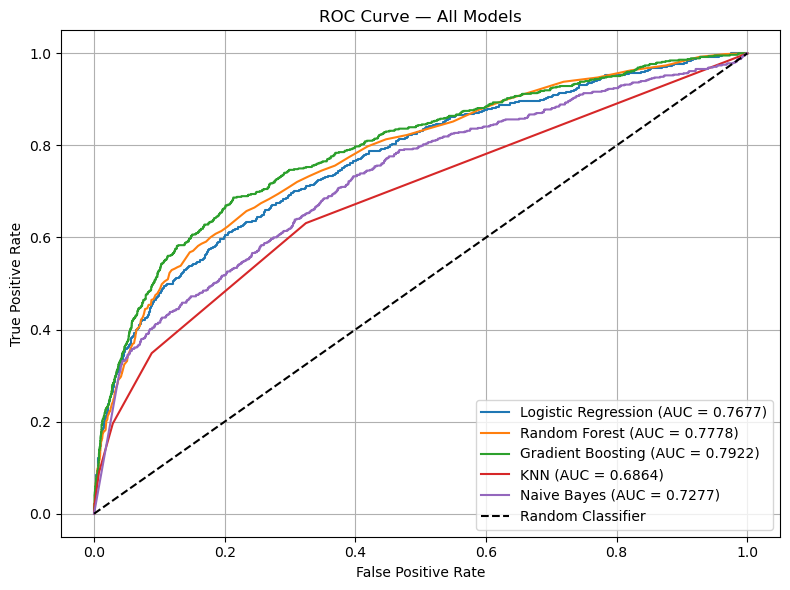

In [36]:
# we'll do a plot of ROC-AUC for all models so we cna visualise the classification more easily 

# plot ROC curves for all models — following LAB6 approach
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['roc_auc']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# random classifier reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.14 - Model evaluations and assessments


**Results**
- GB has the best ROC-AUC score at 0.7922
- GB has best F1 score at .337
- RF and GB  have accuracy rates of  at 89% but this is predicting mostly typeA in out imbalanced dataset
- Recall  - of all customers how many did we identify?
- Precision - of all we predicted as TypeB how many actually were type B. Low precision means wasting time ringing people, which means costs for the business
- False negative  = Missing a real lead (lost revenue) 
- False Positive =  calling people who won't buy (extra costs for the business)

**Models and Evaluation**
- Log Reg  - has recall of 62.96% but precision  = 26.93%  => 3 out of every 4 customers it flags as TypeB customers aren't TpeB.
- NB - 2nd highest Recall at 43.36% but 2nd lowest precision 33.8% => 2 out of every 3 customers if predicts as TypeB are not TypeB
- GB - Recall = 23.7% and Precision = 58.33% => conservative at default threshold of 0.5, misses 76% of TypeB customers, however best ability to separate the classes TypeA and TypeB
- RF - Recall  = 19% and Precision  = 59% => very conservative, when predicts TypeB its right 59% of time
- KNN - Recall  = 19.6% and Precision = 47.92% - only predicts one out of 5 typeB and is accurate only 47% of the time.
- All the models are being evaluated at the default threshold classification value of 0.5. Threshold tuning may improve the recall and precision trade off for some models.
- Different models do have different behaviours in terms of evaluation metrics, somr with high recall and low precision, and others with low recall and higher precision.

**Model Selection**
- ROC-AUC is an important metric for us in that it show how well the model is able to separate the classes, then Precision and Recall become  relevant for the business in that they define how many good leads we  cna find and how may bad leads we cna avoid.
- The ROC-AUC plot shows GB as having the greatest separation, all models having some predictive separation value though. KNN is the weakest at approx 68%
- Business wants to identify as many customers as possible without wasting too much time on calls with people who won't buy. Its a marketing campaign so does not need to be overly conservative, but does not want to spend lots of time chasing bad leads.

## Step 4 - Model Tuning and validation

### 4.1 - Threshold Tuning

In [37]:
# we will run threshold tuning on the GB model, which was our bet classifier form earlier results.
# default threshold value is 0.5, we wil try different values and see which gives the best recall and precision values  
y_prob_gb = results['Gradient Boosting']['y_prob']

gb_probs = results['Gradient Boosting']['y_prob']

# test a range of thresholds
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("====== Threshold Tuning for GB model ======")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-" * 60)

for thresh in thresholds:
    y_pred_thresh = (gb_probs >= thresh).astype(int)
    print(f"{thresh:<12.2f} "
          f"{precision_score(y_test, y_pred_thresh):<12.4f} "
          f"{recall_score(y_test, y_pred_thresh):<12.4f} "
          f"{f1_score(y_test, y_pred_thresh):<12.4f} "
          f"{accuracy_score(y_test, y_pred_thresh):<12.4f}")

====== Threshold Tuning for GB model ======
Threshold    Precision    Recall       F1           Accuracy    
------------------------------------------------------------
0.10         0.2773       0.6944       0.3963       0.7486      
0.15         0.3867       0.5664       0.4596       0.8417      
0.20         0.4358       0.4815       0.4575       0.8643      
0.25         0.4705       0.4306       0.4496       0.8747      
0.30         0.4951       0.3873       0.4346       0.8802      
0.35         0.5124       0.3519       0.4172       0.8832      
0.40         0.5442       0.3133       0.3976       0.8872      
0.45         0.5687       0.2809       0.3760       0.8892      
0.50         0.5833       0.2377       0.3377       0.8892      


### 4.2 - Threshold Tuning results

- As the threshold is lowered the Precision reduces, from '.6' to '.44' when going from threshold values of 0.5 to 0.2. This means one in two customers are genuine TYpeB customers.
- Conversely the Recall increases from 23% to 47%
- There is a trade off between improving recall i.e capturing more potential leads, and increasing false positive i.e. watsign effort on non TypeB individuals.
- F1 score is the Harmonic mean of both Precision and Recall and we obtain the highest F1 score at 0.2 threshold value, which indicates the best balance between the two.
- This means the model is catching nearly half of all TYpeB customers at a threshold of 0.2
- 0.2 will be our the threshold value that we will use.

### 4.3 - Cross Validation 

We will not use the model generated here. Rather we perform cross validation to verify the model selection decision from earlier.

In [38]:
# cross validation will provide a more robust estimate of model performance than single 80/20 split
# define 5 models for use in CV
# class weight is not used for GB, KNN and NB, it adjusts weight inversely proportional to the class frequency
# we use the drop=first parameter to avoid collinearity for the linear models, drop reference category
# n_estimators - number of trees to build, default is 100, tried different values

# we define stratified which defines how to split the data, this preserves the 88/12 split in each fold.
# for our imbalanced data set using cv=5 didn't guarantee stratification , we had an issue wth it and have to explicitly define stratification outside
# # define parameter to be called later
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define the evaluatio metrics we'll use
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# define the models and their parameters
models_cv = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'         : GaussianNB()
}


print(" === 5-Fold Cross Validation Results === ")
for name, model in models_cv.items():
    # redefine preprocessor must be  unfitted fresh instance for cross validation, this avoids data leaakge across the folds
    preprocessor_cv = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_pre_split)
])
    

    pipeline_cv = Pipeline(steps=[
        ('preprocessor', preprocessor_cv),
        ('classifier', model)
    ])
    print(f"\nEvaluation metrics for {name}:")
    cv_results = cross_validate(pipeline_cv, X, y, cv=cv, scoring=scoring)
    for metric in scoring:
        # get the metric name
        scores = cv_results[f'test_{metric}']
        # we'll include the standard deviation also so we can see the variation and consistency across the different folds
        # low values std dev  = stable and generaliseable / high std dev = bigger variation and possible overfitting perhaps
        print(f"  {metric:<12}  = {scores.mean():.4f} (+/- {scores.std():.4f})")

 === 5-Fold Cross Validation Results === 

Evaluation metrics for Logistic Regression:
  accuracy      = 0.7621 (+/- 0.0053)
  precision     = 0.2799 (+/- 0.0068)
  recall        = 0.6360 (+/- 0.0160)
  f1            = 0.3887 (+/- 0.0088)
  roc_auc       = 0.7705 (+/- 0.0086)

Evaluation metrics for Random Forest:
  accuracy      = 0.8911 (+/- 0.0021)
  precision     = 0.6350 (+/- 0.0304)
  recall        = 0.1980 (+/- 0.0076)
  f1            = 0.3018 (+/- 0.0117)
  roc_auc       = 0.7760 (+/- 0.0062)

Evaluation metrics for Gradient Boosting:
  accuracy      = 0.8931 (+/- 0.0016)
  precision     = 0.6472 (+/- 0.0237)
  recall        = 0.2233 (+/- 0.0046)
  f1            = 0.3320 (+/- 0.0068)
  roc_auc       = 0.7960 (+/- 0.0067)

Evaluation metrics for KNN:
  accuracy      = 0.8828 (+/- 0.0037)
  precision     = 0.5208 (+/- 0.0446)
  recall        = 0.1823 (+/- 0.0136)
  f1            = 0.2700 (+/- 0.0209)
  roc_auc       = 0.6874 (+/- 0.0055)

Evaluation metrics for Naive Bayes:
  acc

### 4.4 - Cross Validation results

Cross validation was applied to all 5 models from earlier. Stratified folds were applied to keep the 88/12 class ratio across each fold.
Results are consistent with holdout - Gradient boosting remains the strongest model in terms of ROC-AUC .796
- Low standard deviations across all models suggest  stability

- GB best ROC-AUC = 0.7960 (holdout 0.7922)
- RF second = 0.7760 (holdout 0.7778)
- LR = 0.7705 (holdout 0.7677)
- NB = 0.7316 (holdout 0.7277)
- KNN weakest = 0.6874 (holdout 0.6864)

We will not use the model generated here. Rather we perform cross validation to verify the model selection decision.

- confirms that GB is consistently the best model, across different splits. 


### 4.5 - Address Imbalance using Oversmapling

In [39]:
# we'll try deal with the imbalanced dataset by using Random over sampler and see if the results from that are netter than our threshold 
# will duplicate synthetic typeB values to address the imbalance
# will balance the training data before mdoel fitting
# reference  - [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html)


rndm_over_samp = RandomOverSampler(random_state=42)

# we'll create a new pre-processor for this here, so keep it independent and clean from others
# wil transform here and fitted inside pipelien on training data only
preprocessor_rndm_over_samp = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_pre_split)
])

# use imblearn Pipeline not sklearn Pipeline
# will apply to training data only during fit
# we wil onyl run agaimst one model , chosing oru bets model and see if it improves performance
# will duplicate typeB rows to balance the data
rndm_over_samp_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_rndm_over_samp),
    ('oversampler', rndm_over_samp),
    ('classifier',   GradientBoostingClassifier(n_estimators=100,  random_state=42))
])

# we'll fit the pipeline on the training data
rndm_over_samp_pipe.fit(X_train, y_train)
# runs X_test on the pipeline and will return class prediction  0 or 1 for each row. oversampling not applied to test data
y_pred_ros = rndm_over_samp_pipe.predict(X_test)
# returns probability score instead of class labels, take proba of being typeB for each row
y_prob_ros = rndm_over_samp_pipe.predict_proba(X_test)[:, 1]

# view the evaluation metrics 
print(f" === Gradient Boosting  with  Random Over Sampler for Imbalance ==== ")
print(f" Accuracy = {accuracy_score(y_test, y_pred_ros):.4f}")
print(f" Precision = {precision_score(y_test, y_pred_ros):.4f}")
print(f" Recall  = {recall_score(y_test, y_pred_ros):.4f}")
print(f"AUC = {roc_auc_score(y_test, y_prob_ros):.4f}")
print(f"F1  = {f1_score(y_test, y_pred_ros):.4f}")
print(classification_report(y_test, y_pred_ros, target_names=['TypeA','TypeB']))

 === Gradient Boosting  with  Random Over Sampler for Imbalance ==== 
 Accuracy = 0.7937
 Precision = 0.3153
 Recall  = 0.6281
AUC = 0.7905
F1  = 0.4198
              precision    recall  f1-score   support

       TypeA       0.94      0.82      0.87      4805
       TypeB       0.32      0.63      0.42       648

    accuracy                           0.79      5453
   macro avg       0.63      0.72      0.65      5453
weighted avg       0.87      0.79      0.82      5453



### 4.6 - RandomOverSampler results

- ROC-AUC is worse at 0.7905 compared to 0.7922 for threshold tuning
- Recall improved to 62,81%, precision dropped to 31.53% , meaaning approx 2 out of 3 customers are not good leads
- Overall GB with threshold tuning value of 0.2 remains our best model

### 4.7 - Parameter tuning using GridsearchCV

we'll run grid search CV in an attempt to identify the best paramsters to use on our prefer model Gradient Boosting

In [40]:
# we'll us gridsearch to identify best paramaters to use for gradient boostign, our prefereed model identified earli in threshol tuning
# reference [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

# print out a hodling text valeu to let us knwo its running
print(" === running GridSearchCV  for  Gradient Boosting model === ")


# we'll create a new pre-processor for this here, so keep it independent and clean from others
# wil transform here and fitted inside pipelien ontraining data only
preprocessor_gs = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_pre_split)
])

# parameter grid to search, combination of hyperparameter
# reduced grid — fewer combinations s was takign lnig time to run every time
# 2 x 2 x 2  = 8 combinations x 5 folds = 40 fits
# should run in 5-10 min - minimised it to run in 4 mins...
param_grid = {
    'classifier__n_estimators'  : [100, 200,],
    'classifier__learning_rate' : [0.05, 0.1],
    'classifier__max_depth'     : [3, 4,],
}

#grid seach pipeline preprocessor and GB classifier call
gs_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_gs),
    ('classifier',   GradientBoostingClassifier(random_state=42))
])

# search using all parameter combinations using stratified 2 fold cross validation
# we'll only look at one evaluation metric to keep it simple and to reduce run time
grid_search = GridSearchCV(
    gs_pipe,
    param_grid    = param_grid,
    cv            = StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring       = 'roc_auc',
    n_jobs        = -1,
    verbose       = 1
)

# fit on the training daa only
grid_search.fit(X_train, y_train)

# have a look at the best parameters and best score
print(f"\nBest parameters  =  {grid_search.best_params_}")
print(f"Best CV AUC      =  {grid_search.best_score_:.4f}")

# evaluate best model on test set
# best estimator is the complete fitted pipeline with the best hyperparamater combination found
best_gs    = grid_search.best_estimator_
y_pred_best_gs  = best_gs.predict(X_test)
y_prob_best_gs = best_gs.predict_proba(X_test)[:, 1]

# view all combinations ranked by score
scores_df = pd.DataFrame(grid_search.cv_results_)
scores_df = scores_df.sort_values(by=['rank_test_score']).reset_index(drop=True)
print(scores_df[['rank_test_score', 'mean_test_score', 'param_classifier__n_estimators', 'param_classifier__learning_rate',                 'param_classifier__max_depth']].to_string(index=False))


print(f"\n=== tuned GradientBoosting on test set ===")
print(f"Accuracy = {accuracy_score(y_test, y_pred_best_gs):.4f}")
print(f" Precision = {precision_score(y_test, y_pred_best_gs):.4f}")
print(f" Recall  = {recall_score(y_test, y_pred_best_gs):.4f}")
print(f"ROC-AUC  = {roc_auc_score(y_test, y_prob_best_gs):.4f}")
print(f"F1       = {f1_score(y_test, y_pred_best_gs):.4f}")
print(f"\n{classification_report(y_test, y_pred_best_gs, target_names=['TypeA','TypeB'])}")

 === running GridSearchCV  for  Gradient Boosting model === 
Fitting 2 folds for each of 8 candidates, totalling 16 fits

Best parameters  =  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV AUC      =  0.7937
 rank_test_score  mean_test_score  param_classifier__n_estimators  param_classifier__learning_rate  param_classifier__max_depth
               1         0.793698                             200                             0.10                            3
               2         0.792268                             200                             0.05                            4
               3         0.791633                             200                             0.10                            4
               4         0.791067                             100                             0.10                            4
               5         0.790642                             100                             0

### 4.8 - Parameter tuning using GridsearchCV Results

- Gridsearch identified
    - learning_rate = 0.1
    - max_depth = 3
    - n_estimators = 200
    - as the best parameter values giving an roc-auc value of 0.7937
- with a precision of 0.5833 and recall of 0.2377 for typeB, these values tells us it performs the same as the threshold tuning model, with a threshold of 0.5
    - of all customers it predicts as TypeB 58% are actually typeB
    - it is only identifying 24% of the actual number of TypeB individuals
- Moving the threshold tuning value from 0.5 to 0.2 will have a great er impact in improving the recall and precision numbers then modifying the hyperamaters i.e. threshold = 0.2 => recall was = 47.22% and precision was = 45.64% 

## Step 5 - Predict Query data set outcomes

### 5.1 - Generate Prediction on Query set using threshold value of 0.2

In [41]:
# we'll use the last clean dataframe values we had which was '_7'

# prepare query features (drop target column)
X_query = df_qry_7.drop(columns=['y'])

# check shape and columns match and are as we expect training features before continuing
print(f"X_query shape  = {X_query.shape}")
print(f"X_train shape  = {X_train.shape}")
print(f"columns match  =  {X_query.columns.tolist() == X.columns.tolist()}")
# '?' means we haven't touched it, which is what we want.
print(f"query 'y' values = {df_qry_7['y'].unique()}")

# set probabilities using best pipeline
# pipeline applies RobustScaler and OneHotEncoder automatically
# the pipeline ie being called from when we initialyl fitted in section 3
# pipeline applied fitted robust scalar and one hod encoding to query data
best_pipe = results['Gradient Boosting']['pipeline']
# applying the already fitted preprocessor transformation to the query data then runs the fitted GB classifier
# returns a probability for each class type, two columns one for typeA and one for TypeB
# take only the typeB column , so we get oen probability per row
q_prob    = best_pipe.predict_proba(X_query)[:, 1]

# check the probability values from the predict_proba above
# check for suspiciously narrow range in orobabilities, want spread of values to show different confidence levels from model on different individual types, i.e. close to '0' = confident typeA and close to '1' = confident its typeB  
print(f"\n === probability distribution check ===")
print(f"min prob  : {q_prob.min():.4f}")
print(f"max prob  : {q_prob.max():.4f}")
print(f"mean prob : {q_prob.mean():.4f}")
print(f"std prob  : {q_prob.std():.4f}")

# distribution of probabilities in buckets
print(f"\n === probability distribution === ")
buckets = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for i in range(len(buckets)-1):
    count = ((q_prob >= buckets[i]) & (q_prob < buckets[i+1])).sum()
    pct   = count / len(q_prob) * 100
    print(f"  {buckets[i]:.1f} - {buckets[i+1]:.1f}  = {count:,}  ({pct:.1f}%)")


#  apply threshold 0.20, returns an array of 0s and 1s, converts true/false booelan resutl to int
# anythgin above 0.2 becoems TypeB / anythgn below becoes TypeA
q_pred_binary = (q_prob >= 0.20).astype(int)

#  map 0s and 1s back to TypeA / TypeB labels, using key valeu pairs
label_map     = {0: 'TypeA', 1: 'TypeB'}
q_pred_labels = [label_map[p] for p in q_pred_binary]

# view the predictions
print(f"\n === query data set predictions ===")
print(f"total rows        : {len(q_pred_labels):,}")
print(f"TypeA predictions : {q_pred_labels.count('TypeA'):,}")
print(f"TypeB predictions : {q_pred_labels.count('TypeB'):,}")
print(f"TypeB rate        : {q_pred_labels.count('TypeB')/len(q_pred_labels)*100:.1f}%")
print(f"\n counts match query rows : {len(q_pred_labels) == len(df_qry_7)}")
print(f"\n first 10 predictions    : {q_pred_labels[:10]}")



X_query shape  = (17939, 16)
X_train shape  = (21812, 16)
columns match  =  True
query 'y' values = ['?']

 === probability distribution check ===
min prob  : 0.0109
max prob  : 0.9828
mean prob : 0.1174
std prob  : 0.1503

 === probability distribution === 
  0.0 - 0.1  = 12,885  (71.8%)
  0.1 - 0.2  = 2,840  (15.8%)
  0.2 - 0.3  = 624  (3.5%)
  0.3 - 0.4  = 475  (2.6%)
  0.4 - 0.5  = 318  (1.8%)
  0.5 - 0.6  = 239  (1.3%)
  0.6 - 0.7  = 187  (1.0%)
  0.7 - 0.8  = 192  (1.1%)
  0.8 - 0.9  = 143  (0.8%)
  0.9 - 1.0  = 36  (0.2%)

 === query data set predictions ===
total rows        : 17,939
TypeA predictions : 15,725
TypeB predictions : 2,214
TypeB rate        : 12.3%

 counts match query rows : True

 first 10 predictions    : ['TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA']


### 5.2 - Query Data set prediction results

- 71.8% of customers are < 0.1, this is as expected as majority of individuals are TypeA
- There is a min probability of 0.0109 and a max probability value of 0.928, so model is not skewed in one direction and has confident predictions of TypeA and TypeB, which shows it seems to be performing well.
- TypeB has a prediction rate of 12.3%, this matches the training data so gives us confidence the model is good, not over or under fitted.
- There is a min probability of 0.0109 and a ax probability value of 0.928, so model is not 
- First 10 predictions are all TypeA, which is as expected to have such a high number given the % of both
- num ber of predictions = to the number of rows in thr query data set  = True , as a verification check.

### 5.3 - Generate answer file 

In [42]:
# NOTE this will re-use the prediction values generated earlier in section 5.1. and the variable 'q_pred_labels' so section 5.1 has to have run successfully in order for this code to run successfully..

# student number for use in file name
student_number = 'D24127620'
# designating the file name format
file_name = f"{student_number}.txt"


# file content must be in the format '1,TypeA' per row and for 17,939 rows.
# create df with two rows query and prediction
# query number is length of prediction labels from section 5.1, so from 1 to 17,939, one per row. index starts at '0' so we add 1 from start.
# prediction column contains 'TypeA' or 'TypeB' value for each row in the query data set.
final_ans_df = pd.DataFrame({'query': range(1, len(q_pred_labels) + 1),'prediction': q_pred_labels})
final_ans_df.to_csv(file_name, index=False, header=False)


print(f" === submission file verification === ")
print(f"file name        : {file_name}")
print(f"file size        : {os.path.getsize(file_name):,} bytes")

# double check the file and contents
final_ans_file = pd.read_csv(file_name, header=None, names=['query', 'prediction'])
print(f"rows in file     =  {len(final_ans_file):,}  ==== must equal ====  17,939")
print(f" index number unique values    = {final_ans_file['query'].unique()} ==== must equal ====  1 ...... 17939")
print(f" Type labels unique values    = {final_ans_file['prediction'].unique()}  ==== must equal ====  'TypeA' / 'TypeB'")
print(f"TypeA count      = {(final_ans_file['prediction'] == 'TypeA').sum():,}  ==== must equal ====  15,725")
print(f"TypeB count      = {(final_ans_file['prediction'] == 'TypeB').sum():,}  ==== must equal ====  2,214")
print(f"\n first few rows:")
print(final_ans_file.head(4).to_string(index=False))
print(f"\n last few rows:")
print(final_ans_file.tail(4).to_string(index=False))


 === submission file verification === 
file name        : D24127620.txt
file size        : 222,101 bytes
rows in file     =  17,939  ==== must equal ====  17,939
 index number unique values    = [    1     2     3 ... 17937 17938 17939] ==== must equal ====  1 ...... 17939
 Type labels unique values    = ['TypeA' 'TypeB']  ==== must equal ====  'TypeA' / 'TypeB'
TypeA count      = 15,725  ==== must equal ====  15,725
TypeB count      = 2,214  ==== must equal ====  2,214

 first few rows:
 query prediction
     1      TypeA
     2      TypeA
     3      TypeA
     4      TypeA

 last few rows:
 query prediction
 17936      TypeB
 17937      TypeB
 17938      TypeA
 17939      TypeB


## Step 6 - Conclusions

**Model Selection**
- GradientBoosting with a classification threshold value of 0.2 was selected as te best model as it provided a balance between precision and recall reducing the false positives (flagged as TypeB outcomes but not i.e. wasted time and effort) and obtaining as many typeB individuals as possible.
- This Model appears to be performing reasonably well and predicts 12.3 % of query data to be TypeB outcome individuals. which is consistent wit the training data class distribution.
- Use of a probabilistic model is useful as it allows us modify the threshold value to tune the model as necessary, and the use of the threshold tuning allowed us the flexibility to obtain the desired balance between precision and recall.

**Key Findings**
- 'pdays' was identified as the strongest numerical predictor using Information Gain. (0.0228)
- 'poutcome' was identified as the strongest predictor feature from exploratory analysis. Individuals who had a TypeB outcome in a previous campaign were converted to TypeB 66.78% of the time, the highest rate for any feature.
- Predictive value for categorical features using chi squared was also looked at. The results from chi squared test showed 'contact' and 'education' as having greater statistical significance than 'poutcome', however both EDA conversion rates, section 2.16, and model behaviour both indicate 'poutcome' as having the greater influence on 'TypeB' outcome. Imbalance in those features may be the underlining cause of that result. It would require further investigation which is beyond the time limits with this assignment.
- Evaluation metrics of 'Precision' and 'Recall' are the best evaluators due to the imbalance in the data, and these in combination with ROC-AUC to identify the classification separation performance. 
- Accuracy was an unreliable evaluation metric due to the imbalance in the data. Values of around 89% were returned in some instances as they were just accurately predicting the dominant class. 
- In our case Threshold tuning in a probabilistic model proved to be more flexible than gridsearch hyperparameter tuning, or oversampling. It gave a better performance return for effort required in coding and compute time.
- Different models showed different behaviour, Logistic regression achieved high recall but lower precision, whereas tree based models such as gradient Boosting achieved higher precision but lower recall.

**Future areas to investigate**
- We looked at using wrapper feature selection but were unable to complete it due to time constraints. May be beneficial to revisit
- Additional feature engineering could also be looked at to perhaps.
- Predictive statistical significance of the features to resolve the conflicting signals concerning 'contact', 'eductaion' and 'poutcome', 
- Neural Networks could also be tried as a future area of investigation.
- Our GridsearchCV was good but limited in scope due to the length of tie it was taking to run for each iteration and change. With more time this coudl be a good area to pursue to try make improvements in the model ie.. a larger grid and more parameters.